ERD

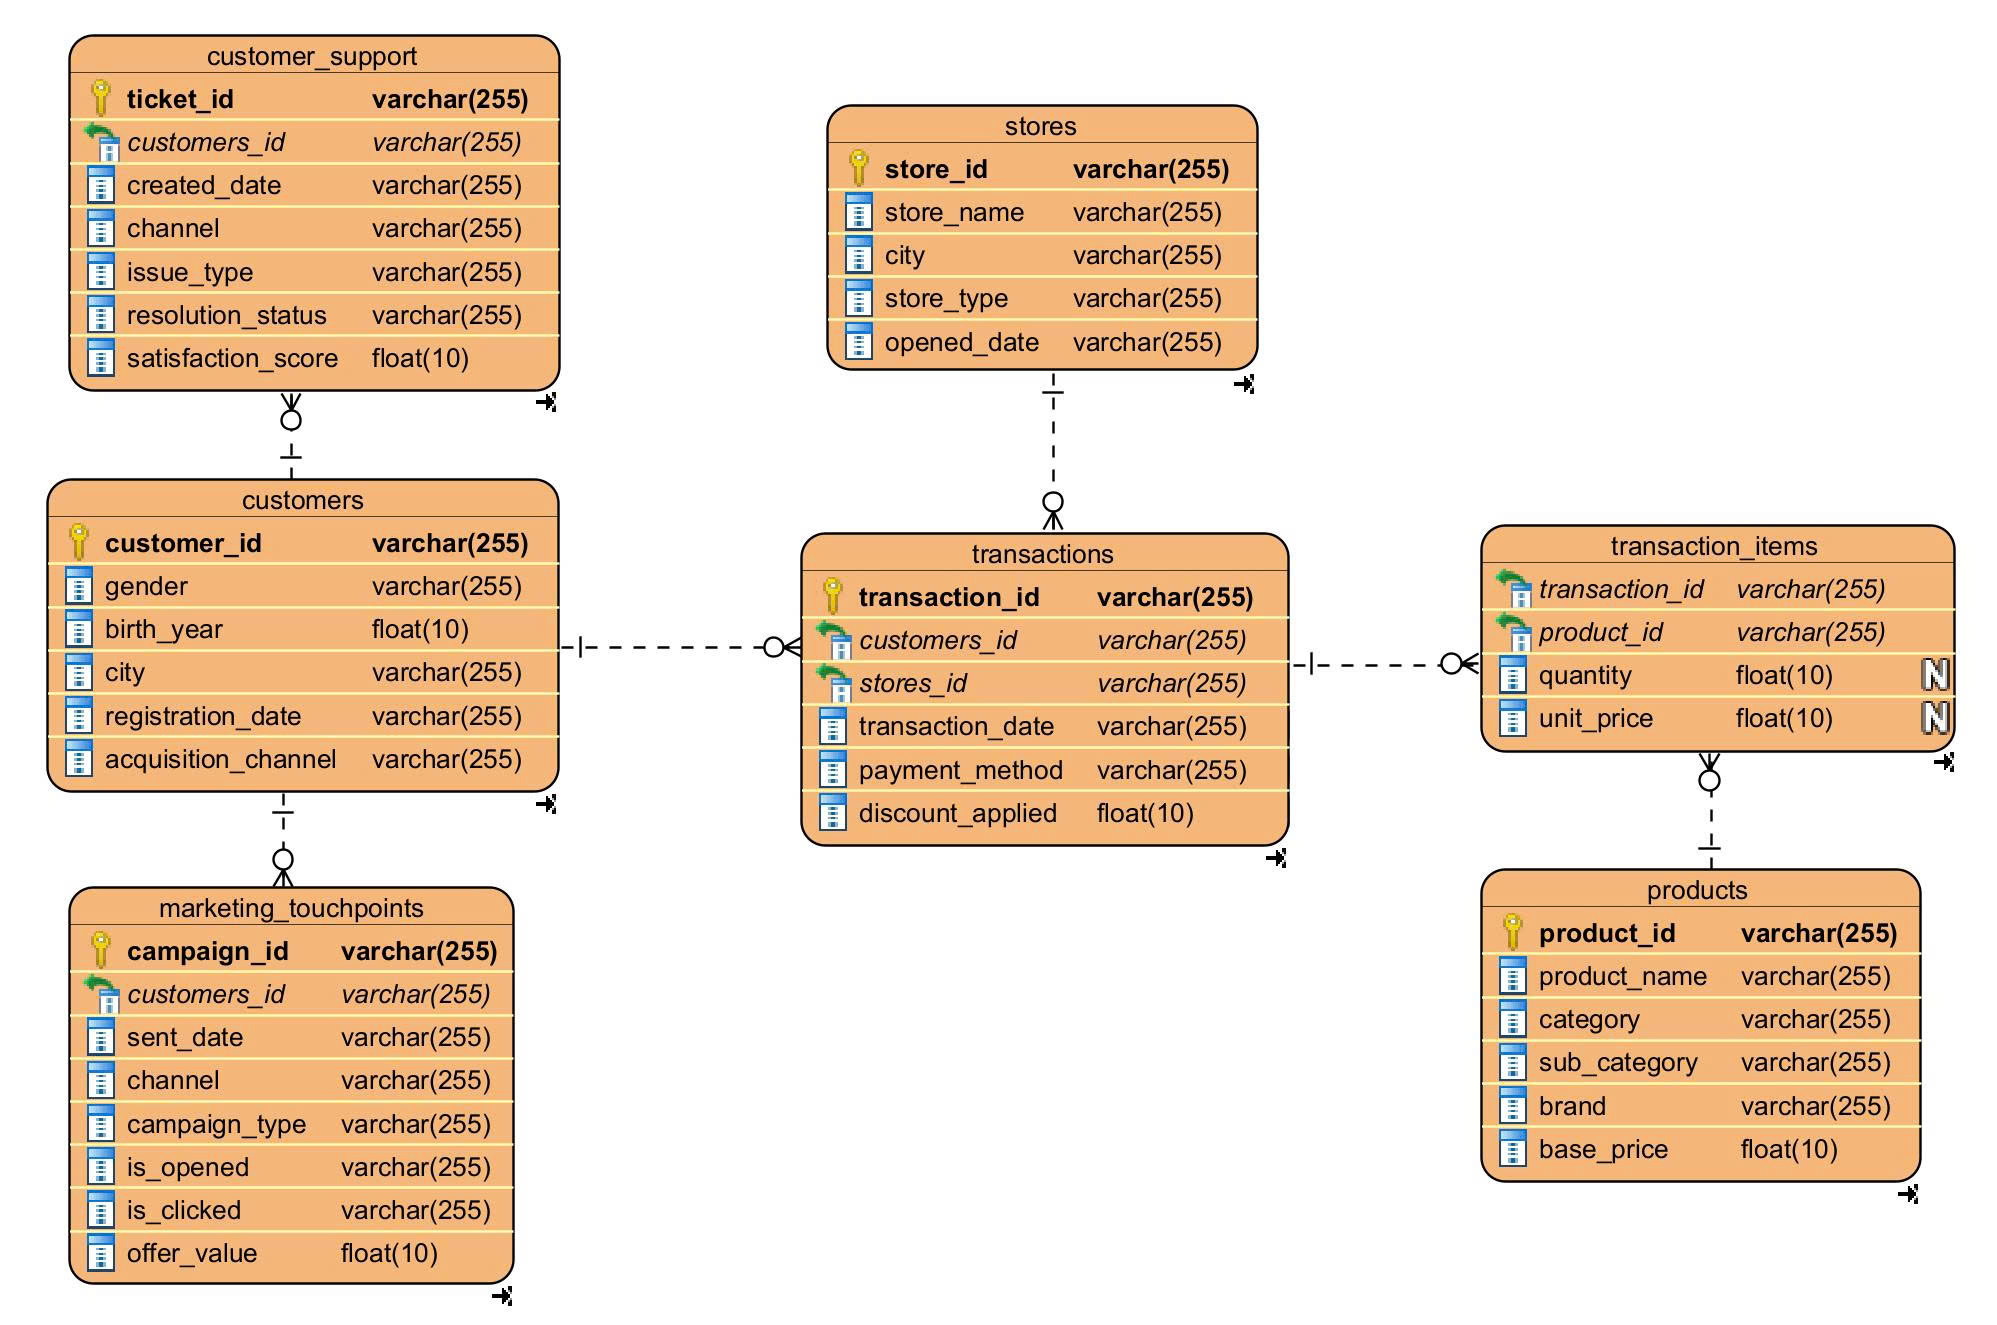

In [153]:
from IPython.display import Image, display

display(Image(filename='./images/erd_diagram.jpg', width=1000))

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Customers

EDA + Data cleaning cho từng cột trong bảng customers

Kiểm tra tổng quát

In [2]:
customer_data = pd.read_csv('./data/customers.csv')
customer_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          800 non-null    str    
 1   gender               757 non-null    str    
 2   birth_year           760 non-null    float64
 3   city                 760 non-null    str    
 4   registration_date    784 non-null    str    
 5   acquisition_channel  760 non-null    str    
dtypes: float64(1), str(5)
memory usage: 37.6 KB


In [3]:
customer_data.describe()

,birth_year
count,760.000000
mean,2124.466632
std,1656.591121
min,-1985.000000
25%,1975.000000
50%,1986.000000
75%,1996.000000
max,19990.000000


Missing values

In [4]:
customer_data.isnull().sum()

customer_id             0
gender                 43
birth_year             40
city                   40
registration_date      16
acquisition_channel    40
dtype: int64

EDA + Data cleaning cho cột gender

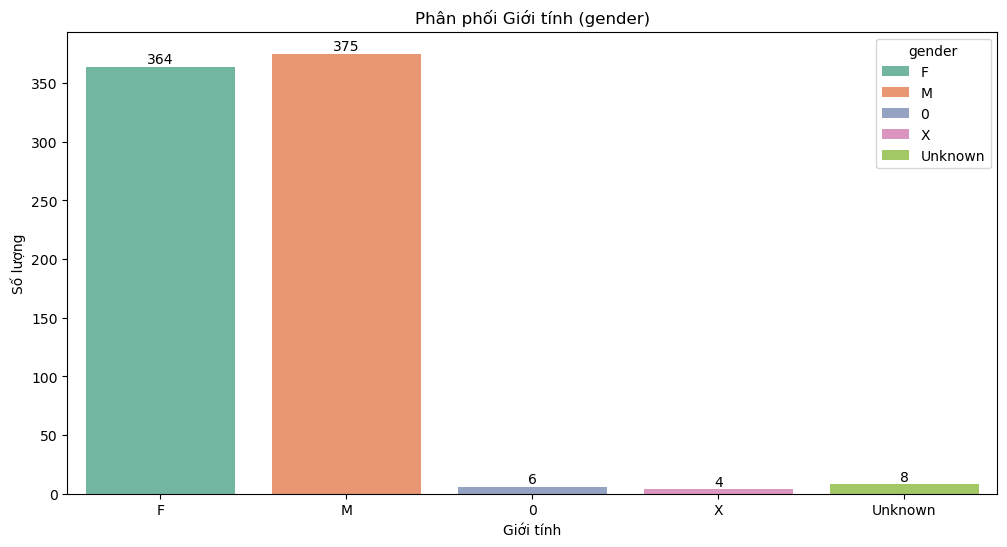

In [5]:
# Biểu đồ: Đếm số lượng theo Giới tính (gender) để tìm Dữ liệu không hợp lệ
plt.figure(figsize=(12, 6))
plt.subplot(1, 1, 1)

ax1 = sns.countplot(data=customer_data, x='gender', hue='gender', palette='Set2')
plt.title('Phân phối Giới tính (gender)')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax1.containers:
    ax1.bar_label(container)

Có 5 loại giá trị là F-Female, M-Male, 0 (6 giá trị), X (4 giá trị), Unknown (8 giá trị) và 43 giá trị bị null:
->Giữ lại các giá trị categorical F, M và Unknown
->Các giá trị 0, X và null sẽ được chuyển thành Unknown để không làm sai lệch dữ liệu thực tế (IMPUTE) vì thực tế có một số khách hàng không muốn đề cập đến giới tính (gender)

In [6]:
from sklearn.impute import SimpleImputer
customer_data['gender'] = customer_data['gender'].replace(['0', 'X'], np.nan)
imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Unknown')
customer_data['gender'] = imputer.fit_transform(customer_data[['gender']]).ravel()

print(customer_data['gender'].value_counts(dropna=False))

gender
M          375
F          364
Unknown     61
Name: count, dtype: int64


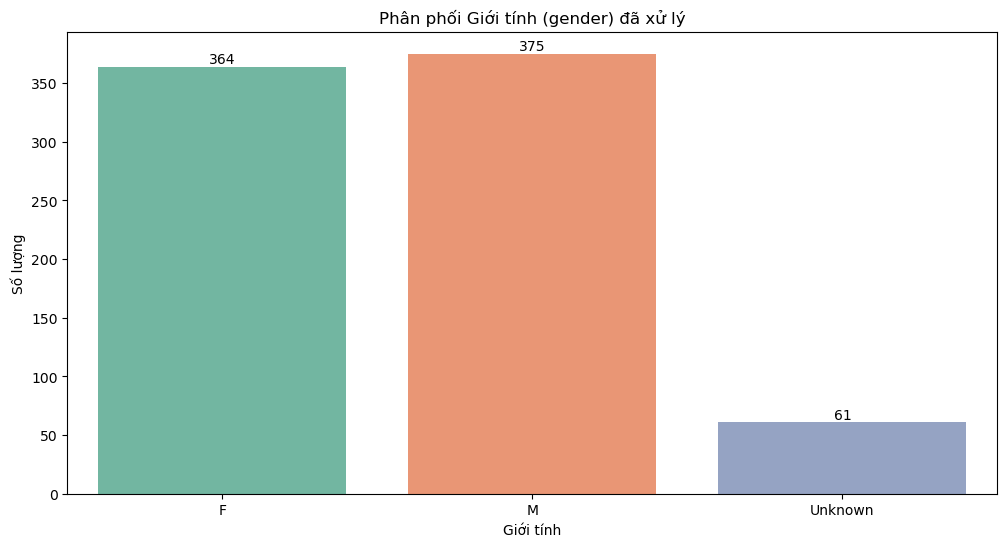

In [7]:
# Biểu đồ: Đếm số lượng theo Giới tính (gender) đã xử lý
plt.figure(figsize=(12, 6))
plt.subplot(1, 1, 1)

ax2 = sns.countplot(data=customer_data, x='gender', hue='gender', palette='Set2')
plt.title('Phân phối Giới tính (gender) đã xử lý')
plt.xlabel('Giới tính')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax2.containers:
    ax2.bar_label(container)

EDA + Data cleaning cho cột birth_year

Xử lý giá trị âm cho năm sinh

In [8]:
print("--- 1. TÌM GIÁ TRỊ ÂM ---")
# Kiểm tra giá trị âm trong cột birth_year
negative_birth_years = customer_data[customer_data['birth_year'] < 0]
print(f"Số lượng khách hàng có năm sinh âm: {len(negative_birth_years)}")
if len(negative_birth_years) > 0:
    display(negative_birth_years)

--- 1. TÌM GIÁ TRỊ ÂM ---
Số lượng khách hàng có năm sinh âm: 3


,customer_id,gender,birth_year,city,registration_date,acquisition_channel
339,C00340,M,-1985.0,Vũng Tàu,2023-10-31,Walk-in
562,C00563,F,-1966.0,Buôn Ma Thuột,2024-02-10,Referral
779,C00780,F,-1980.0,Biên Hòa,2024-10-16,Referral


Vì các năm sinh có giá trị âm nằm trong các khoảng chấp nhận được, có thể do trong quá trình thu thập bị sai sót, và vì có 3 giá trị nên sẽ lấy trị tuyệt đối cho các giá trị này.

In [9]:
customer_data['birth_year'] = customer_data['birth_year'].abs()
print(f"Số lượng năm sinh âm sau khi xử lý: {len(customer_data[customer_data['birth_year'] < 0])}")

Số lượng năm sinh âm sau khi xử lý: 0


Xử lý outliers và giá trị null cho birth_year 


Dựa vào quy định của pháp luật thì khách hàng đủ 15 là tuổi vị thành niên và chịu trách nhiệm trước pháp luật được, còn đối với người già từ 85 tuổi trở đi sẽ ít minh mẫn hơn để đặt hàng nên đặt khoảng hợp lệ (1940, 2011) để tìm outlier và xử lý.

In [10]:
print("--- TÌM OUTLIER DỰA TRÊN LOGIC THỰC TẾ ---")
# Giả sử khách hàng hợp lệ sinh từ năm 1940 đến 2011
outlier_logic = customer_data[(customer_data['birth_year'] < 1940) | (customer_data['birth_year'] > 2011)]
print(f"Số lượng outliers theo logic (trước 1940 hoặc sau 2011): {len(outlier_logic)}")

--- TÌM OUTLIER DỰA TRÊN LOGIC THỰC TẾ ---
Số lượng outliers theo logic (trước 1940 hoặc sau 2011): 15


In [11]:
if len(outlier_logic) > 0:
    display(outlier_logic)

,customer_id,gender,birth_year,city,registration_date,acquisition_channel
62,C00063,M,19980.00,Hải Phòng,2024-12-21,Google
120,C00121,M,19.85,Thủ Đức,2024-07-25,Website
276,C00277,F,19670.00,Cần Thơ,2023-08-04,TikTok
318,C00319,F,5952.00,Huế,2024-02-06,Google
360,C00361,F,19730.00,TP.HCM,2024-12-27,TikTok
394,C00395,M,19.99,Hà Nội,2024-00-00,Google
432,C00433,M,19990.00,NaN,2023-11-21,Zalo
575,C00576,M,19940.00,Vũng Tàu,2024-08-18,Facebook
595,C00596,M,19.89,Thủ Đức,01-2024-15,Referral
600,C00601,M,5991.00,Đà Nẵng,2025-01-15,Shopee


Có tổng cộng 15 outliers và 40 missing values trên tổng số 800 giá trị của cột, chiếm hơn 7% vì thế không thể loại bỏ giá trị này, mà sẽ chuyển toàn bộ giá trị và điền NaN giá trị median để tránh ảnh hưởng mất thông tin, trung vị đại diện cho độ tuổi trung bình của tệp khách hàng phù hợp để xử lý trong trường hợp này, chuyển float thành int cho phù hợp kiểu năm sinh.

In [12]:
from sklearn.impute import SimpleImputer
customer_data.loc[(customer_data['birth_year'] < 1940) | (customer_data['birth_year'] > 2011), 'birth_year'] = np.nan

imputer = SimpleImputer(missing_values=np.nan, strategy='median')
customer_data['birth_year'] = imputer.fit_transform(customer_data[['birth_year']]).ravel().astype(int)

In [13]:
customer_data.describe()

,birth_year
count,800.000000
mean,1985.706250
std,11.387474
min,1965.000000
25%,1976.000000
50%,1986.000000
75%,1994.250000
max,2006.000000


EDA + Data cleaning cho cột city

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\1636835510.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.countplot(data=customer_data, x='city', palette='Set2')


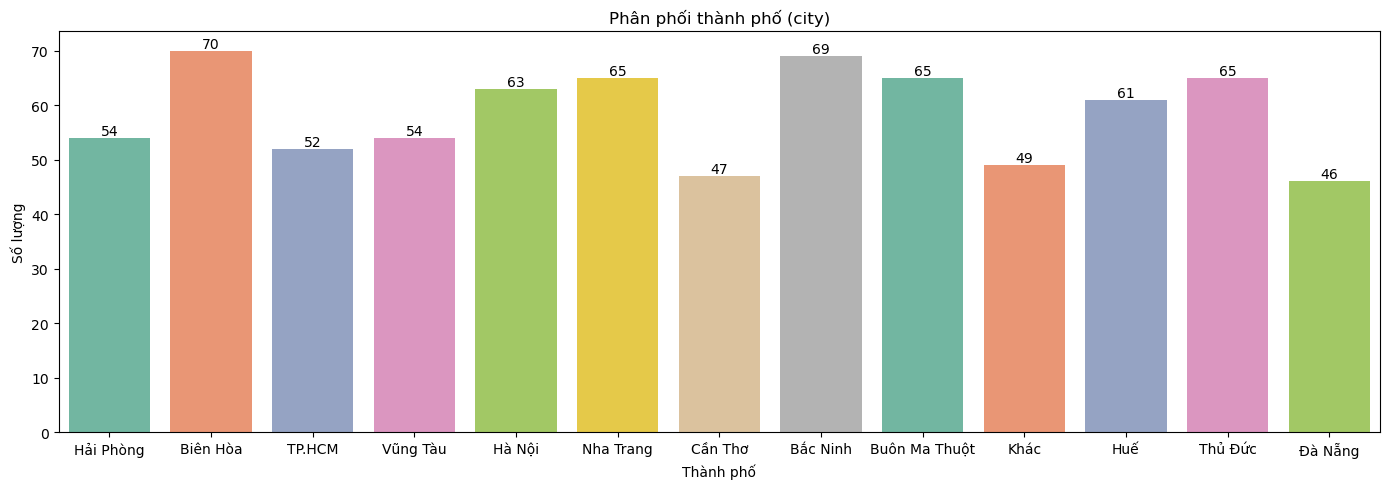

In [14]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 1, 1)
ax3 = sns.countplot(data=customer_data, x='city', palette='Set2')
plt.title('Phân phối thành phố (city)')
plt.xlabel('Thành phố')
plt.ylabel('Số lượng')

for container in ax3.containers:
    ax3.bar_label(container)

plt.tight_layout()
plt.show()

Theo biểu đồ thì phân phối các thành phố khá đồng đều, đồng thời missing value thường là những dữ liệu chưa thu tập được, nên đưa dữ liệu missing này vào nhóm 'Khác' để tránh bias khi sử dụng mode làm tăng số lượng mà không có cơ sở thực tế.

In [15]:
from sklearn.impute import SimpleImputer

imputer_city = SimpleImputer(strategy='constant', fill_value='Khác')
customer_data['city'] = imputer_city.fit_transform(customer_data[['city']]).ravel()

EDA + Data cleaning cho cột registration_date

In [16]:
print("--- 1. KIỂM TRA ĐỊNH DẠNG YYYY-MM-DD ---")
# Sử dụng Regex để tìm các dòng có định dạng đúng YYYY-MM-DD
regex_pattern = r'^\d{4}-\d{2}-\d{2}$'
valid_format_mask = customer_data['registration_date'].str.match(regex_pattern, na=False)

# Lọc ra các dòng không đúng định dạng
invalid_dates = customer_data[~valid_format_mask & customer_data['registration_date'].notnull()]
print(f"Số lượng dữ liệu KHÔNG đúng định dạng YYYY-MM-DD: {len(invalid_dates)}")
if len(invalid_dates) > 0:
    display(invalid_dates[['customer_id', 'registration_date']])

--- 1. KIỂM TRA ĐỊNH DẠNG YYYY-MM-DD ---
Số lượng dữ liệu KHÔNG đúng định dạng YYYY-MM-DD: 8


,customer_id,registration_date
69,C00070,01-2024-15
319,C00320,01-2024-15
371,C00372,01-2024-15
518,C00519,01-2024-15
526,C00527,01-2024-15
595,C00596,01-2024-15
708,C00709,01-2024-15
723,C00724,01-2024-15


Vì các năm sai định dạng là hợp lệ và có giá trị giống nhau nên sẽ chuyển các giá trị này thành dạng đúng 2024-01-15

In [17]:
customer_data.loc[~valid_format_mask, 'registration_date'] = '2024-01-15'

Tìm outliers


---TÌM NĂM OUTLIER TRONG REGISTRATION_DATE ---
Giới hạn hợp lệ (IQR): Từ 2021.5 đến 2025.5
Số lượng Outlier theo IQR: 0


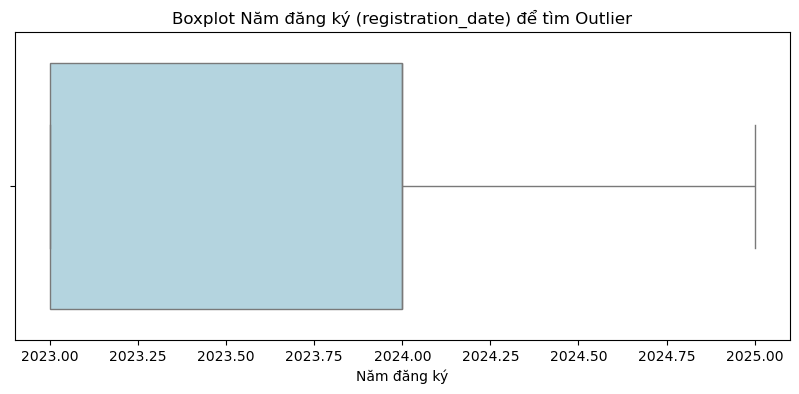

In [18]:
print("\n---TÌM NĂM OUTLIER TRONG REGISTRATION_DATE ---")
# Chuyển đổi an toàn sang datetime (những giá trị lỗi sẽ biến thành NaT)
parsed_dates = pd.to_datetime(customer_data['registration_date'], format='%Y-%m-%d', errors='coerce')

# Trích xuất năm đăng ký và bỏ qua các giá trị NaN
registration_years = parsed_dates.dt.year.dropna()

# Áp dụng IQR để tìm năm outlier
Q1 = registration_years.quantile(0.25)
Q3 = registration_years.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Tìm các outlier của năm đăng ký
outlier_years = registration_years[(registration_years < lower_bound) | (registration_years > upper_bound)]
print(f"Giới hạn hợp lệ (IQR): Từ {lower_bound} đến {upper_bound}")
print(f"Số lượng Outlier theo IQR: {len(outlier_years)}")

# Xem chi tiết khách hàng có năm đăng ký là Outlier
outlier_customers = customer_data.loc[outlier_years.index]
if len(outlier_customers) > 0:
    display(outlier_customers[['customer_id', 'registration_date']].head())

# --- TRỰC QUAN HÓA ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.boxplot(x=registration_years, color='lightblue')
plt.title('Boxplot Năm đăng ký (registration_date) để tìm Outlier')
plt.xlabel('Năm đăng ký')
plt.show()

Không phát hiện outlier, tiếp theo sẽ xử lý 16 giá trị missing value, và số lượng của chúng tương đối nhỏ nên sẽ dùng mode để fill các giá trị này.

In [19]:
# Lấy ngày xuất hiện nhiều nhất
mode_date = customer_data['registration_date'].mode()[0]
print(f"Ngày xuất hiện nhiều nhất: {mode_date}")

Ngày xuất hiện nhiều nhất: 2024-01-15


In [20]:
from sklearn.impute import SimpleImputer

imputer_rgd = SimpleImputer(strategy='most_frequent')
customer_data['registration_date'] = imputer_rgd.fit_transform(customer_data[['registration_date']]).ravel()
print(f"Đã điền 16 giá trị null bằng ngày: {mode_date}")

Đã điền 16 giá trị null bằng ngày: 2024-01-15


Xử lý dữ liệu lỗi không đúng định dạng điền thành mode

In [21]:
customer_data['registration_date'] = pd.to_datetime(customer_data['registration_date'], errors='coerce')
# Đếm số lượng giá trị NaT (tương ứng với các định dạng ngày bị lỗi)
invalid_dates_count = customer_data['registration_date'].isna().sum()

print(f"Số lượng giá trị ngày tháng không hợp lệ (đã biến thành NaT): {invalid_dates_count}")

# Xem thử một vài dòng bị lỗi (nếu có)
if invalid_dates_count > 0:
    display(customer_data[customer_data['registration_date'].isna()])

Số lượng giá trị ngày tháng không hợp lệ (đã biến thành NaT): 3


,customer_id,gender,birth_year,city,registration_date,acquisition_channel
198,C00199,M,2001,Buôn Ma Thuột,NaT,Shopee
304,C00305,M,2004,TP.HCM,NaT,Google
394,C00395,M,1986,Hà Nội,NaT,Google


Có tổng cộng 3 dòng bị lỗi format datetime nên sẽ chuyển thành mode

In [22]:
mode_date = customer_data['registration_date'].mode()[0]
customer_data['registration_date'] = customer_data['registration_date'].fillna(mode_date)

print("Kiểu dữ liệu sau khi sửa lỗi:")
print(customer_data['registration_date'].dtype)

Kiểu dữ liệu sau khi sửa lỗi:
datetime64[us]


Chuyển đổi kiểu dữ liệu thành datetime cho đúng format

In [23]:
customer_data['registration_date'] = pd.to_datetime(customer_data['registration_date'])

print(customer_data['registration_date'].dtype)

datetime64[us]


EDA + Data cleaning cho cột acquisition_channel

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\3696116957.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.countplot(data=customer_data, x='acquisition_channel', palette='Set2')


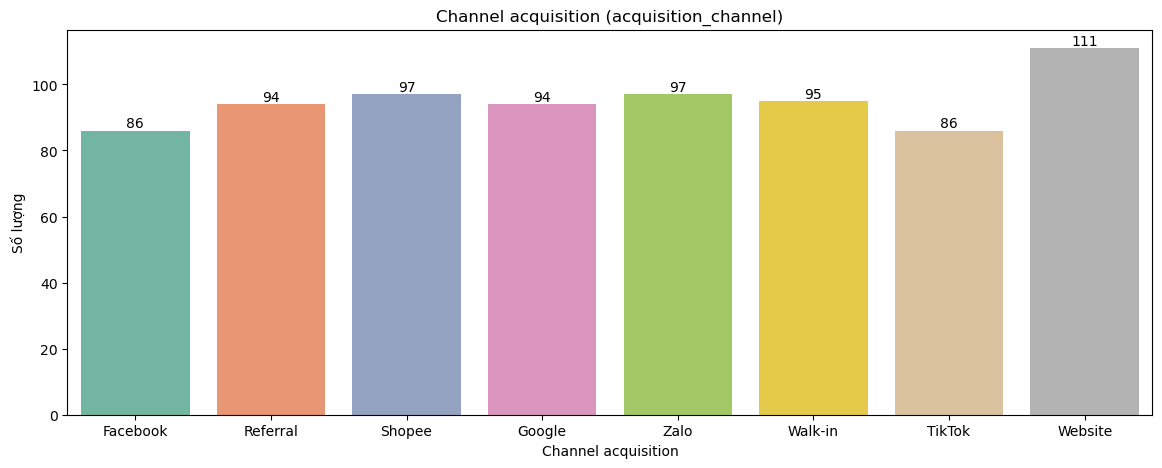

In [24]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 1, 1)
ax4 = sns.countplot(data=customer_data, x='acquisition_channel', palette='Set2')
plt.title('Channel acquisition (acquisition_channel)')
plt.xlabel('Channel acquisition')
plt.ylabel('Số lượng')

for container in ax4.containers:
    ax4.bar_label(container)

Các cột phân bố khá đồng đều, nên 40 missing value sẽ sử dụng fill constant là 'Unknown' để tránh làm bias dữ liệu giữa các cột.

In [25]:
from sklearn.impute import SimpleImputer

imputer_ac = SimpleImputer(strategy='constant', fill_value='Unknown')
customer_data['acquisition_channel'] = imputer_ac.fit_transform(customer_data[['acquisition_channel']]).ravel()

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\3696116957.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.countplot(data=customer_data, x='acquisition_channel', palette='Set2')


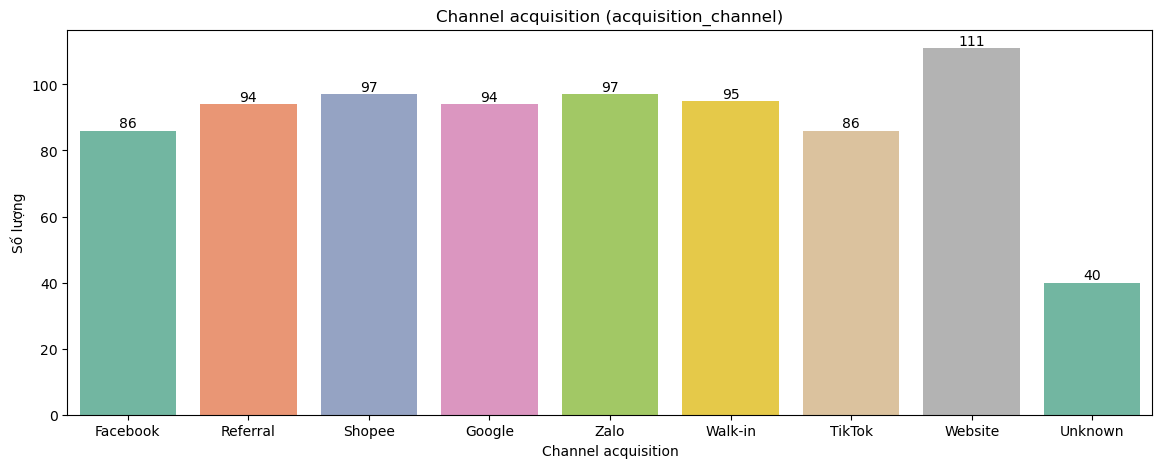

In [26]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 1, 1)
ax4 = sns.countplot(data=customer_data, x='acquisition_channel', palette='Set2')
plt.title('Channel acquisition (acquisition_channel)')
plt.xlabel('Channel acquisition')
plt.ylabel('Số lượng')

for container in ax4.containers:
    ax4.bar_label(container)

In [27]:
customer_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          800 non-null    str           
 1   gender               800 non-null    str           
 2   birth_year           800 non-null    int64         
 3   city                 800 non-null    str           
 4   registration_date    800 non-null    datetime64[us]
 5   acquisition_channel  800 non-null    str           
dtypes: datetime64[us](1), int64(1), str(4)
memory usage: 37.6 KB


EDA + Data cleaning cho từng cột trong bảng customer_support

Kiểm tra tổng quát

In [28]:
customer_support_data = pd.read_csv('./data/customer_support.csv')
customer_support_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ticket_id           700 non-null    str    
 1   customer_id         700 non-null    str    
 2   created_date        700 non-null    str    
 3   channel             671 non-null    str    
 4   issue_type          658 non-null    str    
 5   resolution_status   700 non-null    str    
 6   satisfaction_score  498 non-null    float64
dtypes: float64(1), str(6)
memory usage: 38.4 KB


In [29]:
customer_support_data.head()

,ticket_id,customer_id,created_date,channel,issue_type,resolution_status,satisfaction_score
0,TK00001,C00737,2025-05-05,Facebook,Giao hàng chậm,Closed - No Action,2.0
1,TK00002,C00702,2025-03-28,Tại cửa hàng,Khiếu nại chất lượng,Pending,NaN
2,TK00003,C00701,2025-01-08,Zalo,Đổi trả,Resolved,3.0
3,TK00004,C00765,2025-05-16,Email,Thanh toán lỗi,Resolved,5.0
4,TK00005,C00077,2024-10-27,Zalo,Sai sản phẩm,Resolved,3.0


In [30]:
customer_support_data.describe()

,satisfaction_score
count,498.000000
mean,3.771084
std,7.596979
min,-1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,99.000000


EDA + Data cleaning cột channel

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\2849874411.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax5 = sns.countplot(data=customer_support_data, x='channel', palette='Set2')


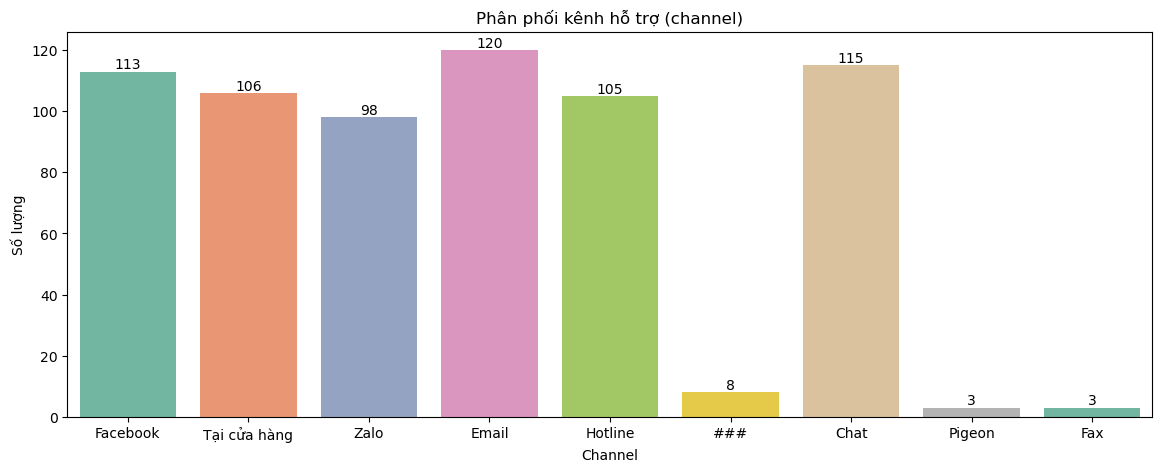

In [31]:
plt.figure(figsize=(14, 5))

# Biểu đồ : Đếm số lượng theo channel để tìm Dữ liệu không hợp lệ
plt.subplot(1, 1, 1)
ax5 = sns.countplot(data=customer_support_data, x='channel', palette='Set2')
plt.title('Phân phối kênh hỗ trợ (channel)')
plt.xlabel('Channel')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax5.containers:
    ax5.bar_label(container)

Có hai loại dữ liệu không hợp lệ là Pigeon và ### tổng của 2 loại này là 11, và missing value là 29. Nên sẽ gộp tất cả vào một danh mục là khác. Vì số lượng các cột còn lại phân bố khá đều nếu sử dụng mode sẽ làm mất cân bằng, và số lượng bản ghi của các outliers này khá ít nên xử lý bằng fill constant sẽ hợp lý nhất.

In [32]:
from sklearn.impute import SimpleImputer
# Chuyển đổi các giá trị không hợp lệ thành NaN
customer_support_data['channel'] = customer_support_data['channel'].replace(['Pigeon', '###'], np.nan)

imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Khác')
customer_support_data['channel'] = imputer.fit_transform(customer_support_data[['channel']]).ravel()

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\2849874411.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax5 = sns.countplot(data=customer_support_data, x='channel', palette='Set2')


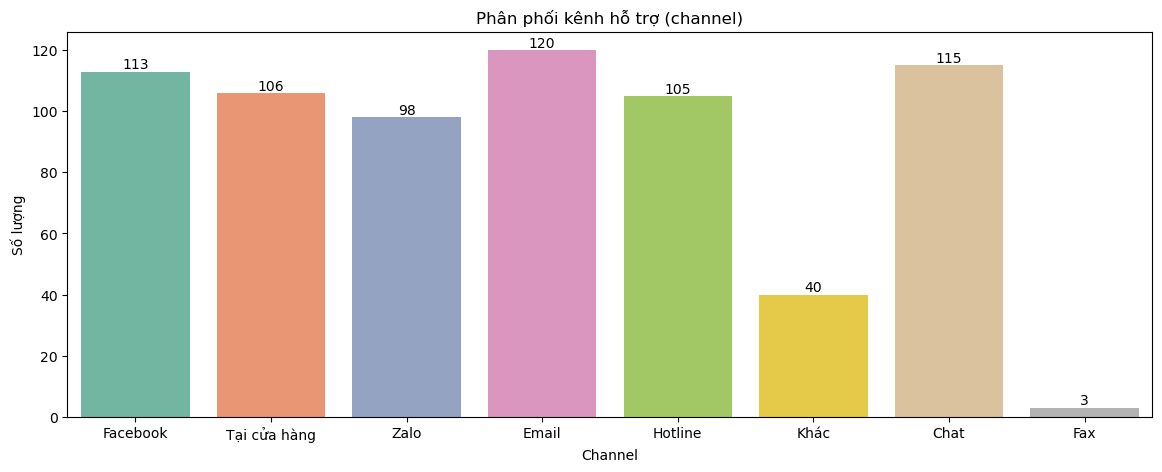

In [33]:
plt.figure(figsize=(14, 5))

# Biểu đồ : Đếm số lượng theo channel để tìm Dữ liệu không hợp lệ
plt.subplot(1, 1, 1)
ax5 = sns.countplot(data=customer_support_data, x='channel', palette='Set2')
plt.title('Phân phối kênh hỗ trợ (channel)')
plt.xlabel('Channel')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax5.containers:
    ax5.bar_label(container)

EDA + Data cleaning cột issue_type

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\685499934.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax6 = sns.countplot(data=customer_support_data, x='issue_type', palette='Set2')


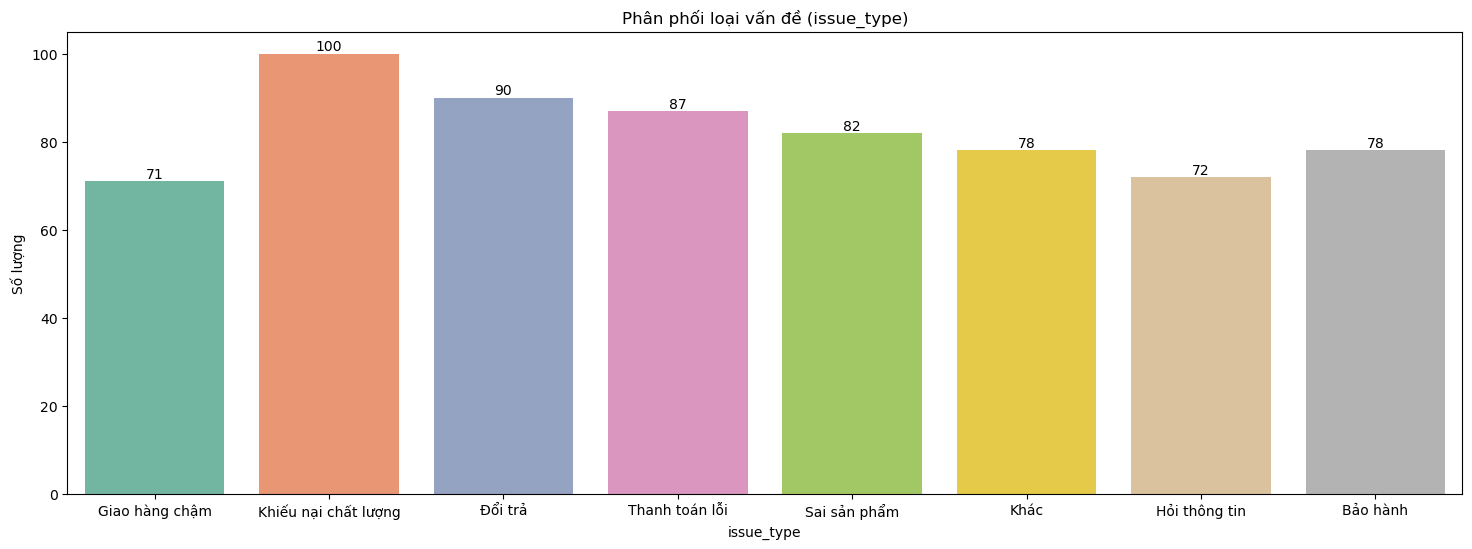

In [34]:
plt.figure(figsize=(18, 6))

# Biểu đồ : Đếm số lượng theo issue type để tìm Dữ liệu không hợp lệ
plt.subplot(1, 1, 1)
ax6 = sns.countplot(data=customer_support_data, x='issue_type', palette='Set2')
plt.title('Phân phối loại vấn đề (issue_type)')
plt.xlabel('issue_type')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax6.containers:
    ax6.bar_label(container)

Có 42 missing value, thực tế thì có những khách hàng chỉ gọi để hỏi về thông tin, cuộc gọi nhỡ hoặc tự giải quyết trực tiếp tại nơi mua hàng. Nên tạo một nhóm riêng 'không vấn đề' để đưa các giá trị missing value này vào, và điều này đảm bảo dữ liệu có thể phản ánh đúng thực thế.

In [35]:
customer_support_data['issue_type'] = customer_support_data['issue_type'].fillna('Không vấn đề')

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\729886437.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax6 = sns.countplot(data=customer_support_data, x='issue_type', palette='Set2')


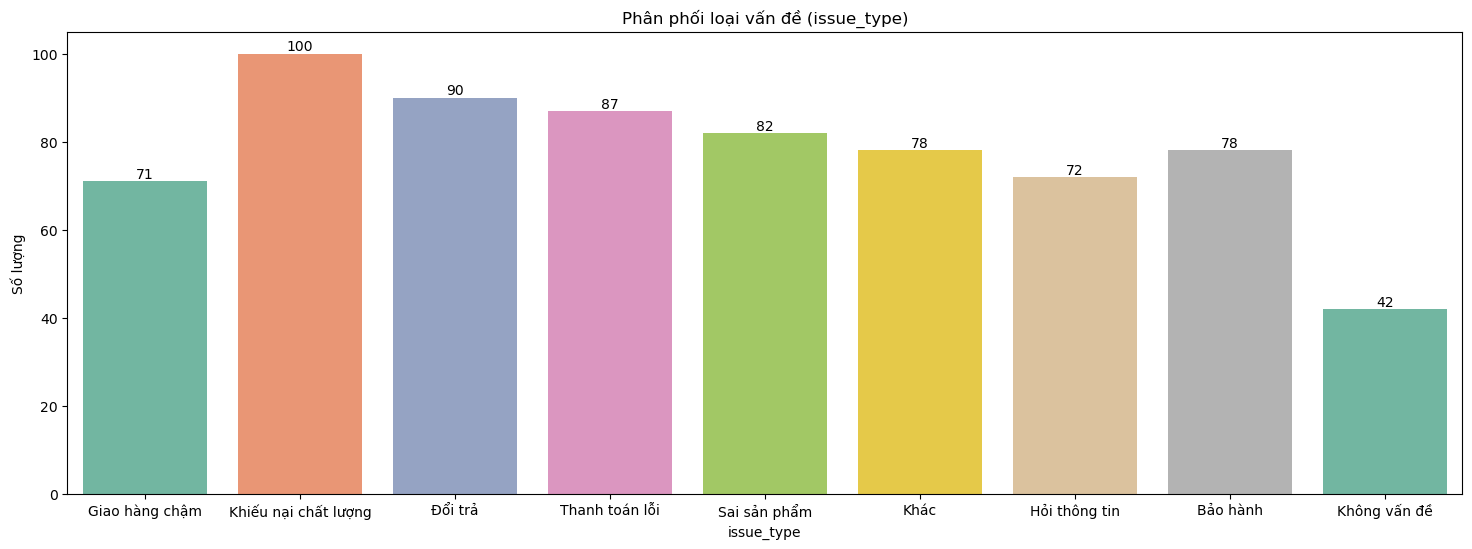

In [36]:
plt.figure(figsize=(18, 6))

#Hiển thị lại biểu đồ sau khi xử lý missing value
plt.subplot(1, 1, 1)
ax6 = sns.countplot(data=customer_support_data, x='issue_type', palette='Set2')
plt.title('Phân phối loại vấn đề (issue_type)')
plt.xlabel('issue_type')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax6.containers:
    ax6.bar_label(container)

EDA + Data cleaning cột satisfaction_score

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\2608310660.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax7 = sns.countplot(data=customer_support_data, x='satisfaction_score', palette='Set2')


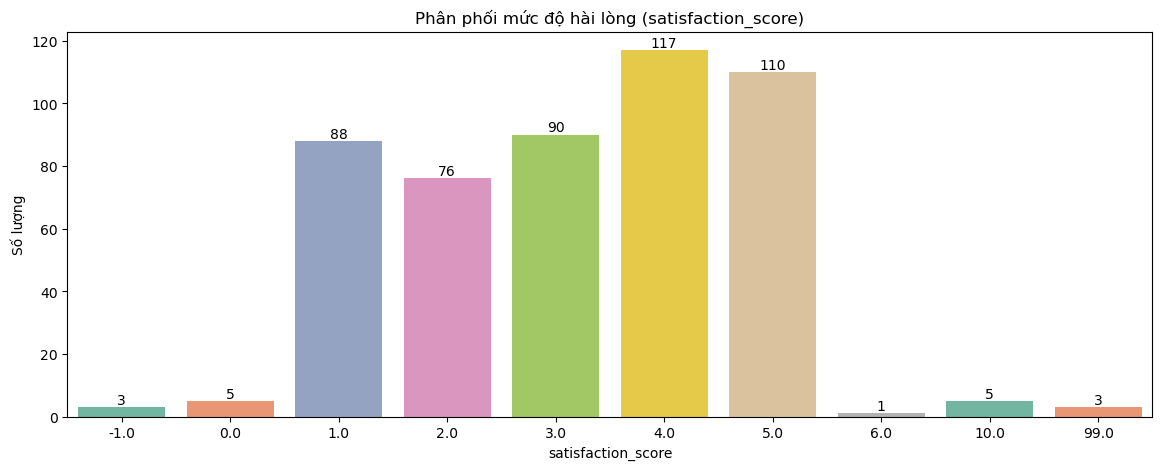

In [37]:
plt.figure(figsize=(14, 5))

# Biểu đồ : Đếm số lượng theo satisfaction score để tìm Dữ liệu không hợp lệ
plt.subplot(1, 1, 1)
ax7 = sns.countplot(data=customer_support_data, x='satisfaction_score', palette='Set2')
plt.title('Phân phối mức độ hài lòng (satisfaction_score)')
plt.xlabel('satisfaction_score')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax7.containers:
    ax7.bar_label(container)

Vì độ hài lòng có tính thứ bậc và có giá trị thuộc [1, 2, 3, 4, 5] nên dùng median sẽ hợp lý, xu hướng trung tâm chuẩn xác nhất và chuyển kiểu dữ liệu cột thành int để phù hợp.

In [38]:
# 1. Lọc và biến các giá trị KHÔNG thuộc [1, 2, 3, 4, 5] thành NaN
valid_scores = [1, 2, 3, 4, 5]
customer_support_data.loc[~customer_support_data['satisfaction_score'].isin(valid_scores), 'satisfaction_score'] = np.nan

median_score = customer_support_data['satisfaction_score'].median()

# 3. Điền toàn bộ NaN bằng median
customer_support_data['satisfaction_score'] = customer_support_data['satisfaction_score'].fillna(median_score)

# 4. Đưa kiểu dữ liệu về số nguyên (int)
customer_support_data['satisfaction_score'] = customer_support_data['satisfaction_score'].astype(int)

# Kiểm tra lại
print(f"Đã điền các giá trị thiếu bằng điểm: {median_score}")
print(customer_support_data['satisfaction_score'].value_counts())

Đã điền các giá trị thiếu bằng điểm: 3.0
satisfaction_score
3    309
4    117
5    110
1     88
2     76
Name: count, dtype: int64


In [39]:
customer_support_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ticket_id           700 non-null    str  
 1   customer_id         700 non-null    str  
 2   created_date        700 non-null    str  
 3   channel             700 non-null    str  
 4   issue_type          700 non-null    str  
 5   resolution_status   700 non-null    str  
 6   satisfaction_score  700 non-null    int64
dtypes: int64(1), str(6)
memory usage: 38.4 KB


EDA + Data cleaning cho cột created_date

--- 1. KIỂM TRA ĐỊNH DẠNG NGÀY THÁNG ---
Số lượng dữ liệu KHÔNG đúng định dạng thời gian: 0

---TÌM OUTLIER TRONG CREATED_DATE ---
Giới hạn năm hợp lệ (IQR): Từ 2022.5 đến 2026.5
Số lượng Outlier theo IQR: 0


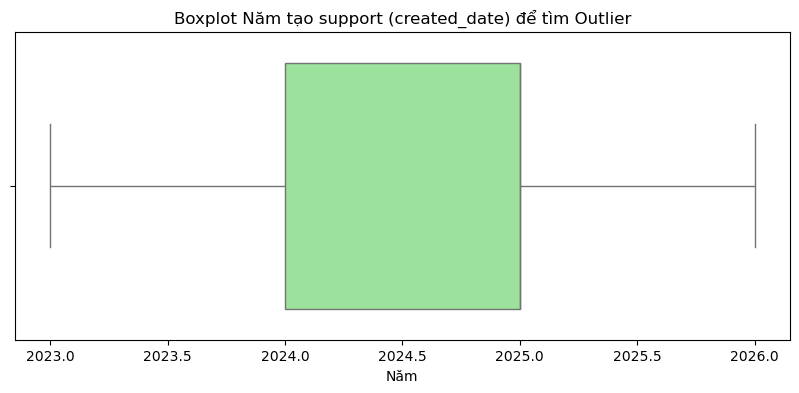

In [40]:
print("--- 1. KIỂM TRA ĐỊNH DẠNG NGÀY THÁNG ---")
# Chuyển đổi an toàn sang datetime (các định dạng lỗi sẽ thành NaT)
parsed_dates = pd.to_datetime(customer_support_data['created_date'], errors='coerce')

# Tìm các dòng bị lỗi định dạng (NaT) nhưng ban đầu không phải null
invalid_format_mask = parsed_dates.isna() & customer_support_data['created_date'].notna()
invalid_dates = customer_support_data[invalid_format_mask]
print(f"Số lượng dữ liệu KHÔNG đúng định dạng thời gian: {len(invalid_dates)}")
if len(invalid_dates) > 0:
    display(invalid_dates[['customer_id', 'created_date']].head())

print("\n---TÌM OUTLIER TRONG CREATED_DATE ---")
# Trích xuất năm để tìm outlier
created_years = parsed_dates.dt.year.dropna()

# Áp dụng IQR để tìm năm outlier
Q1 = created_years.quantile(0.25)
Q3 = created_years.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Tìm các outlier
outlier_years = created_years[(created_years < lower_bound) | (created_years > upper_bound)]
print(f"Giới hạn năm hợp lệ (IQR): Từ {lower_bound} đến {upper_bound}")
print(f"Số lượng Outlier theo IQR: {len(outlier_years)}")

# --- TRỰC QUAN HÓA ---
plt.figure(figsize=(10, 4))
sns.boxplot(x=created_years, color='lightgreen')
plt.title('Boxplot Năm tạo support (created_date) để tìm Outlier')
plt.xlabel('Năm')
plt.show()

In [41]:
# Chuyển kiểu dữ liệu về datetime (sau khi đã xử lý lỗi)
customer_support_data['created_date'] = pd.to_datetime(customer_support_data['created_date'])

In [42]:
customer_support_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ticket_id           700 non-null    str           
 1   customer_id         700 non-null    str           
 2   created_date        700 non-null    datetime64[us]
 3   channel             700 non-null    str           
 4   issue_type          700 non-null    str           
 5   resolution_status   700 non-null    str           
 6   satisfaction_score  700 non-null    int64         
dtypes: datetime64[us](1), int64(1), str(5)
memory usage: 38.4 KB


Products

EDA + Data cleaning cho từng cột trong Products

Kiểm tra tổng quát

In [43]:
product_data = pd.read_csv('./data/products.csv')
product_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    150 non-null    str    
 1   product_name  150 non-null    str    
 2   category      150 non-null    str    
 3   sub_category  150 non-null    str    
 4   brand         141 non-null    str    
 5   base_price    150 non-null    float64
dtypes: float64(1), str(5)
memory usage: 7.2 KB


In [44]:
product_data.tail()

,product_id,product_name,category,sub_category,brand,base_price
145,P0146,Trang điểm_146,Mỹ phẩm,Trang điểm,NaN,1226000.0
146,P0147,Trang điểm_147,Mỹ phẩm,Trang điểm,LOréal,281000.0
147,P0148,Trang điểm_148,Mỹ phẩm,Trang điểm,Local Brand,207000.0
148,P0149,Trang điểm_149,Mỹ phẩm,Trang điểm,Innisfree,1295000.0
149,P0150,Trang điểm_150,Mỹ phẩm,Trang điểm,Innisfree,339000.0


In [45]:
product_data.describe()

,base_price
count,1.500000e+02
mean,2.943587e+06
std,4.931506e+06
min,6.000000e+03
25%,3.105000e+05
50%,1.110000e+06
75%,2.675750e+06
max,2.808900e+07


Xử lý giá trị bị thiếu trong cột brand, sẽ fill constant một cột là 'Unknown' vì thực tế có những của hàng chỉ bán tại nhà, hoặc online thông qua liên hệ zalo hoặc sđt không có tên cửa hàng hoặc có những trường hợp chưa đăng ký hay tạo cửa hàng.

In [46]:
product_data['brand'] = product_data['brand'].fillna('Unknown')

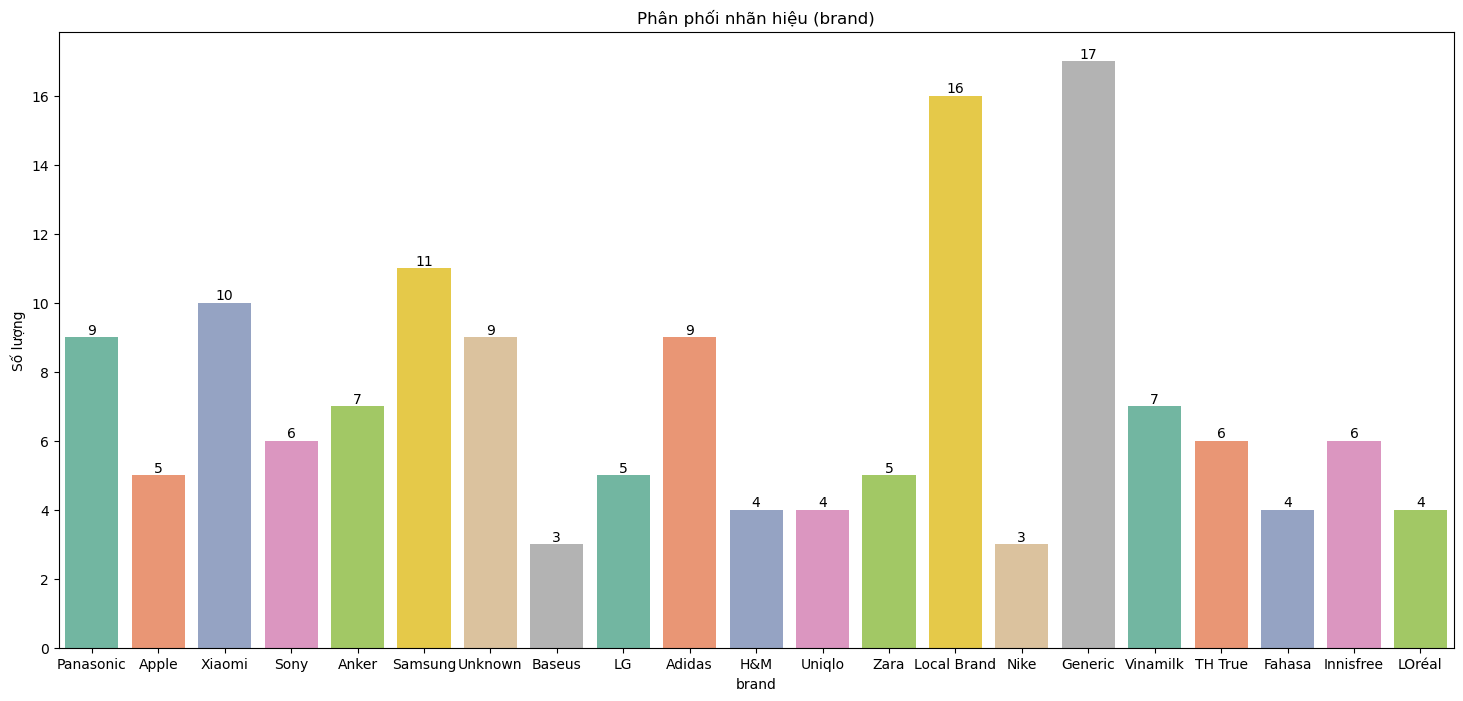

In [47]:
plt.figure(figsize=(18, 8))

# Biểu đồ : Đếm số lượng theo brand
plt.subplot(1, 1, 1)
ax8 = sns.countplot(data=product_data, x='brand', hue='brand',palette='Set2')
plt.title('Phân phối nhãn hiệu (brand)')
plt.xlabel('brand')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax8.containers:
    ax8.bar_label(container)

Stores

EDA + Data cleaning stores

Kiểm tra tổng quát

In [48]:
store_data = pd.read_csv('./data/stores.csv')
store_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   store_id     25 non-null     str  
 1   store_name   25 non-null     str  
 2   city         25 non-null     str  
 3   store_type   25 non-null     str  
 4   opened_date  25 non-null     str  
dtypes: str(5)
memory usage: 1.1 KB


In [49]:
display(store_data)

,store_id,store_name,city,store_type,opened_date
0,S001,Store_A1,TP.HCM,online,2023-08-02
1,S002,Store_A2,Thủ Đức,online,2020-02-21
2,S003,Store_A3,Hải Phòng,online,2021-07-17
3,S004,Store_A4,Đà Nẵng,online,2021-04-02
4,S005,Store_A5,Buôn Ma Thuột,online,2020-07-28
5,S006,Store_A6,TP.HCM,offline,2023-01-21
6,S007,Store_A7,Hà Nội,online,2020-03-06
7,S008,Store_A8,Hải Phòng,online,2021-03-23
8,S009,Store_A9,Hải Phòng,offline,2023-02-23
9,S010,Store_B0,Huế,offline,2021-03-27


In [50]:
#Chuyển opened_date sang datetime
store_data['opened_date'] = pd.to_datetime(store_data['opened_date'], errors='coerce')
print(store_data['opened_date'].dtype)

datetime64[us]


In [51]:
display(store_data)

,store_id,store_name,city,store_type,opened_date
0,S001,Store_A1,TP.HCM,online,2023-08-02
1,S002,Store_A2,Thủ Đức,online,2020-02-21
2,S003,Store_A3,Hải Phòng,online,2021-07-17
3,S004,Store_A4,Đà Nẵng,online,2021-04-02
4,S005,Store_A5,Buôn Ma Thuột,online,2020-07-28
5,S006,Store_A6,TP.HCM,offline,2023-01-21
6,S007,Store_A7,Hà Nội,online,2020-03-06
7,S008,Store_A8,Hải Phòng,online,2021-03-23
8,S009,Store_A9,Hải Phòng,offline,2023-02-23
9,S010,Store_B0,Huế,offline,2021-03-27


In [52]:
store_data.describe()

,opened_date
count,25
mean,2021-07-08 07:40:48
min,2020-01-14 00:00:00
25%,2020-07-08 00:00:00
50%,2021-03-27 00:00:00
75%,2022-07-17 00:00:00
max,2023-08-02 00:00:00


Transaction

EDA + Data cleaning transaction

Kiểm tra tổng quát

In [53]:
transaction_data = pd.read_csv('./data/transactions.csv')
transaction_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    3500 non-null   str    
 1   customer_id       3500 non-null   str    
 2   transaction_date  3500 non-null   str    
 3   store_id          3500 non-null   str    
 4   payment_method    3311 non-null   str    
 5   discount_applied  3335 non-null   float64
dtypes: float64(1), str(5)
memory usage: 164.2 KB


In [54]:
transaction_data.head()

,transaction_id,customer_id,transaction_date,store_id,payment_method,discount_applied
0,T000001,C00301,2025-01-01,S018,Bank Transfer,0.20
1,T000002,C00109,2026-01-07,S014,VNPay,0.00
2,T000003,C00008,2024-11-29,S007,ZaloPay,0.00
3,T000004,C00754,2025-02-26,S010,Cash,0.15
4,T000005,C00268,2025-06-29,S023,ZaloPay,0.05


In [55]:
# kiểm tra các giá trị nan cho từng cột trong transaction_data
transaction_data.isnull().sum()

transaction_id        0
customer_id           0
transaction_date      0
store_id              0
payment_method      189
discount_applied    165
dtype: int64

Kiểm tra định dạng ngày tháng và các giá trị outlier của transaction_date

--- 1. KIỂM TRA ĐỊNH DẠNG NGÀY THÁNG ---
Số lượng dữ liệu KHÔNG đúng định dạng thời gian: 0

---TÌM OUTLIER TRONG TRANSACTION_DATE ---
Giới hạn năm hợp lệ (IQR): Từ 2022.5 đến 2026.5
Số lượng Outlier theo IQR: 0


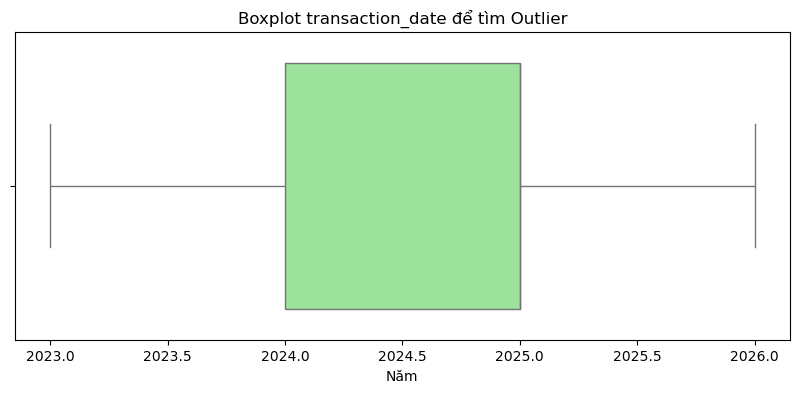

In [56]:
print("--- 1. KIỂM TRA ĐỊNH DẠNG NGÀY THÁNG ---")
# Chuyển đổi an toàn sang datetime (các định dạng lỗi sẽ thành NaT)
parsed_dates = pd.to_datetime(transaction_data['transaction_date'], errors='coerce')

# Tìm các dòng bị lỗi định dạng (NaT) nhưng ban đầu không phải null
invalid_format_mask = parsed_dates.isna() & transaction_data['transaction_date'].notna()
invalid_dates = transaction_data[invalid_format_mask]
print(f"Số lượng dữ liệu KHÔNG đúng định dạng thời gian: {len(invalid_dates)}")
if len(invalid_dates) > 0:
    display(invalid_dates[['customer_id', 'transaction_id', 'transaction_date']].head())

print("\n---TÌM OUTLIER TRONG TRANSACTION_DATE ---")
# Trích xuất năm để tìm outlier
transaction_dates = parsed_dates.dt.year.dropna()

# Áp dụng IQR để tìm năm outlier
Q1 = transaction_dates.quantile(0.25)
Q3 = transaction_dates.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Tìm các outlier
outlier_dates = transaction_dates[(transaction_dates < lower_bound) | (transaction_dates > upper_bound)]
print(f"Giới hạn năm hợp lệ (IQR): Từ {lower_bound} đến {upper_bound}")
print(f"Số lượng Outlier theo IQR: {len(outlier_dates)}")

# --- TRỰC QUAN HÓA ---
plt.figure(figsize=(10, 4))
sns.boxplot(x=transaction_dates, color='lightgreen')
plt.title('Boxplot transaction_date để tìm Outlier')
plt.xlabel('Năm')
plt.show()

In [57]:
#chuyển định dạng transaction_date về datetime sau khi đã xử lý lỗi
transaction_data['transaction_date'] = pd.to_datetime(transaction_data['transaction_date'])
print(transaction_data['transaction_date'].dtype)

datetime64[us]


Kiểm tra đếm số lượng payment_method theo từng loại, phát hiện các giá trị bất thường

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\2756090858.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax9 = sns.countplot(data=transaction_data, x='payment_method', palette='Set2')


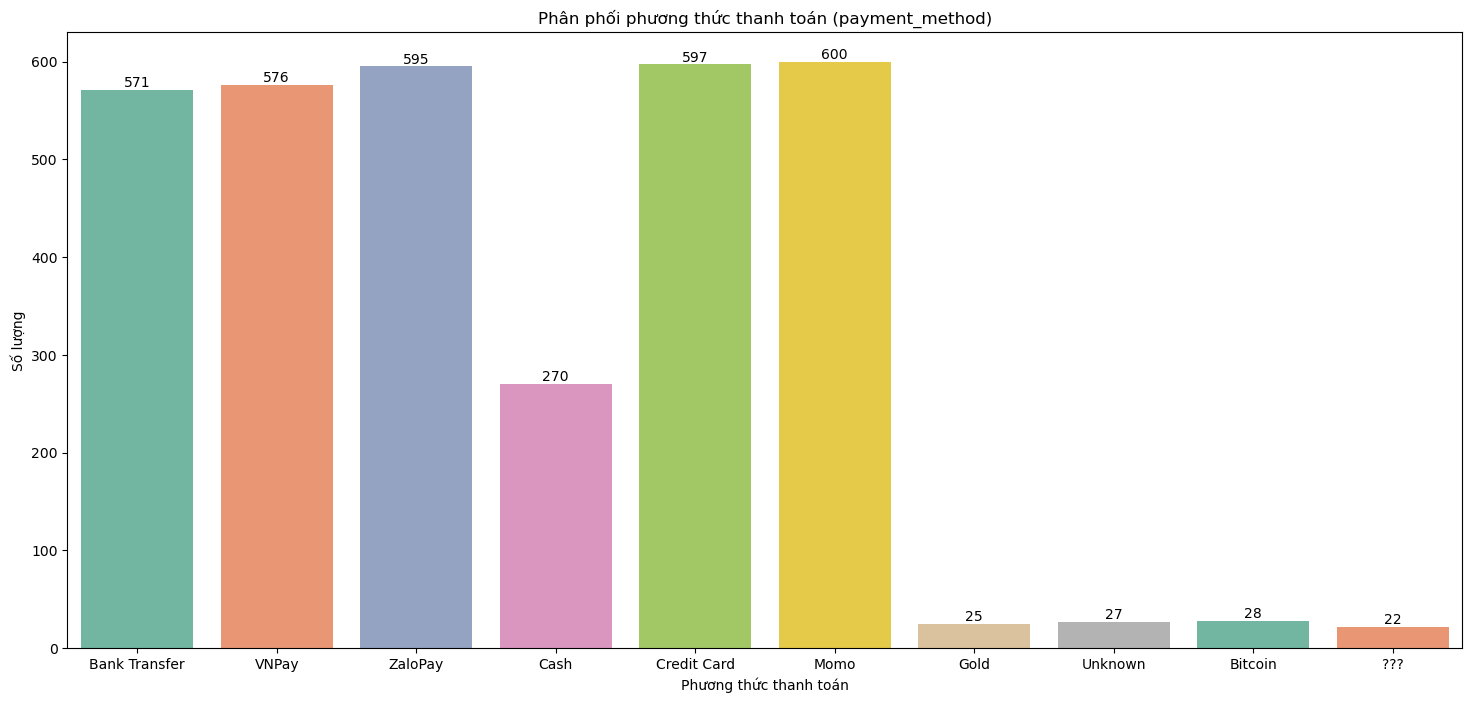

In [58]:
plt.figure(figsize=(18, 8))

# Biểu đồ : Đếm số lượng theo payment_method
plt.subplot(1, 1, 1)
ax9 = sns.countplot(data=transaction_data, x='payment_method', palette='Set2')
plt.title('Phân phối phương thức thanh toán (payment_method)')
plt.xlabel('Phương thức thanh toán')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax9.containers:
    ax9.bar_label(container)

Có 189 missing value và giá trị không hợp lệ như Gold, Bitcoin, ???, Unknown


Để tránh điền bừa vì số lượng các giá trị này khá lớn sẽ làm mô hình dự đoán hành vi sai sau này nên sẽ tạo một cột 'Khác'.

In [59]:
from sklearn.impute import SimpleImputer
# Chuyển đổi các giá trị không hợp lệ thành NaN
transaction_data['payment_method'] = transaction_data['payment_method'].replace(['Gold', 'Unknown', 'Bitcoin', '???'], np.nan)

imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Khác')
transaction_data['payment_method'] = imputer.fit_transform(transaction_data[['payment_method']]).ravel()

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\3332625376.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax9 = sns.countplot(data=transaction_data, x='payment_method', palette='Set2')


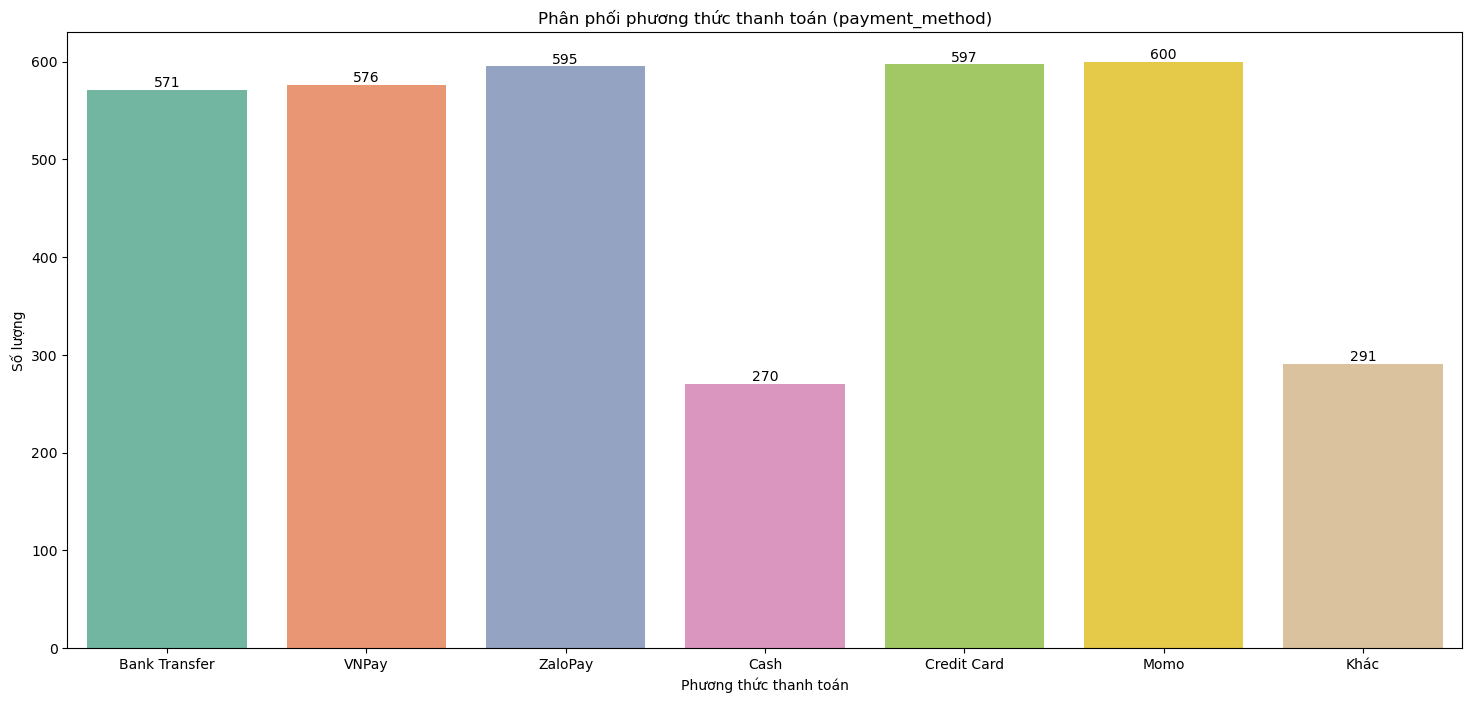

In [60]:
plt.figure(figsize=(18, 8))

# Hiển thị phân phối sau khi xử lý các giá trị không hợp lệ
plt.subplot(1, 1, 1)
ax9 = sns.countplot(data=transaction_data, x='payment_method', palette='Set2')
plt.title('Phân phối phương thức thanh toán (payment_method)')
plt.xlabel('Phương thức thanh toán')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax9.containers:
    ax9.bar_label(container)

EDA + data cleaning cho cột discount_applied

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\1403649899.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax10 = sns.countplot(data=transaction_data, x='discount_applied', palette='Set2')


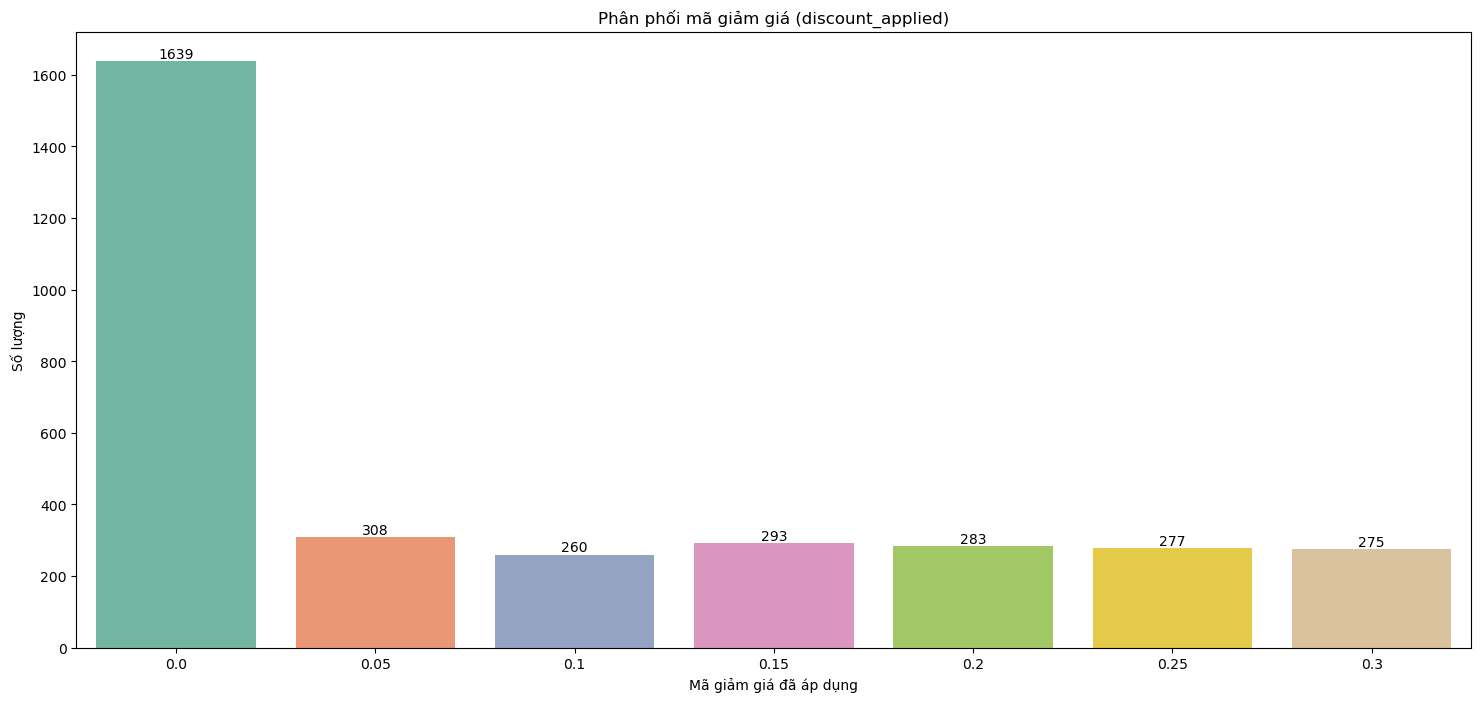

In [61]:
plt.figure(figsize=(18, 8))

# Biểu đồ : Đếm số lượng theo discount_applied để tìm Dữ liệu không hợp lệ
plt.subplot(1, 1, 1)
ax10 = sns.countplot(data=transaction_data, x='discount_applied', palette='Set2')
plt.title('Phân phối mã giảm giá (discount_applied)')
plt.xlabel('Mã giảm giá đã áp dụng')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax10.containers:
    ax10.bar_label(container)

Vì giá trị ở cột 0.0 áp đảo là mode nên sẽ fill giá trị này cho các missing value và vì trong thực tế các missing value để trống có thể là do không có discount cho sản phẩm từ cửa hàng.

In [62]:
mode_date = transaction_data['discount_applied'].mode()[0]
transaction_data['discount_applied'] = transaction_data['discount_applied'].fillna(mode_date)

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\2952381595.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax10 = sns.countplot(data=transaction_data, x='discount_applied', palette='Set2')


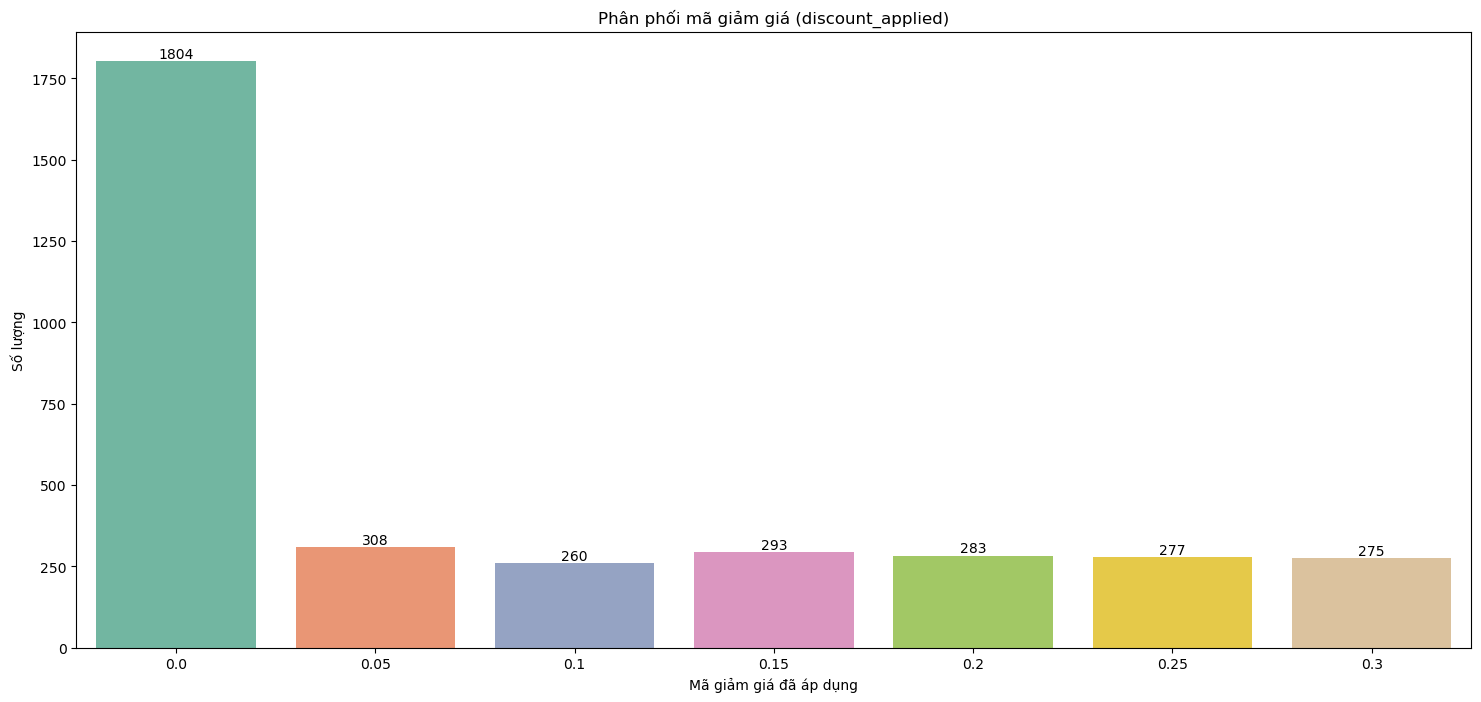

In [63]:
plt.figure(figsize=(18, 8))

#Hiển thị lại biểu đồ sau khi xử lý
plt.subplot(1, 1, 1)
ax10 = sns.countplot(data=transaction_data, x='discount_applied', palette='Set2')
plt.title('Phân phối mã giảm giá (discount_applied)')
plt.xlabel('Mã giảm giá đã áp dụng')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax10.containers:
    ax10.bar_label(container)

marketing touchpoints

EDA + data cleaning marketing touchpoints

kiểm tra tổng quát

In [64]:
marketing_touchpoints_data = pd.read_csv('./data/marketing_touchpoints.csv')
marketing_touchpoints_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   campaign_id    1800 non-null   str    
 1   customer_id    1800 non-null   str    
 2   sent_date      1785 non-null   str    
 3   channel        1699 non-null   str    
 4   campaign_type  1800 non-null   str    
 5   is_opened      1708 non-null   str    
 6   is_clicked     1712 non-null   str    
 7   offer_value    1707 non-null   float64
dtypes: float64(1), str(7)
memory usage: 112.6 KB


In [65]:
marketing_touchpoints_data.isna().sum()

campaign_id        0
customer_id        0
sent_date         15
channel          101
campaign_type      0
is_opened         92
is_clicked        88
offer_value       93
dtype: int64

EDA + Data cleaning cho cột sent_date

--- 1. KIỂM TRA ĐỊNH DẠNG NGÀY THÁNG ---
Số lượng dữ liệu KHÔNG đúng định dạng thời gian: 35


,customer_id,campaign_id,sent_date
14,C00767,MKT016,NaT
24,C00123,MKT026,0000-00-00
46,C00282,MKT048,2024/01/32
95,C00721,MKT047,0000-00-00
131,C00108,MKT033,2024/01/32



---TÌM OUTLIER TRONG SENT_DATE ---
Giới hạn năm hợp lệ (IQR): Từ 2025.0 đến 2025.0
Số lượng Outlier theo IQR: 724


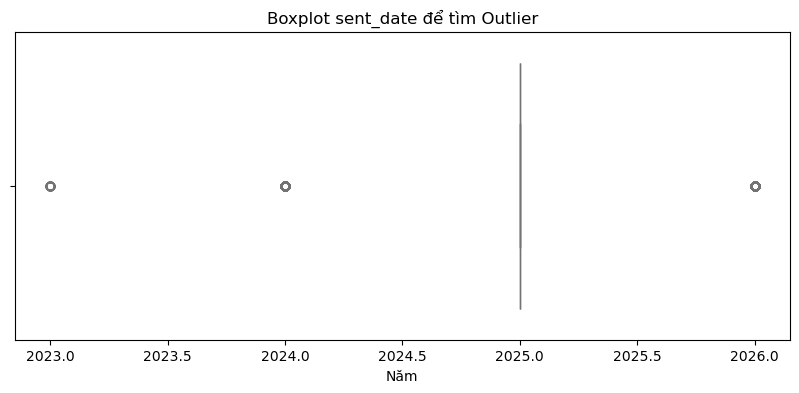

In [66]:
print("--- 1. KIỂM TRA ĐỊNH DẠNG NGÀY THÁNG ---")
# Chuyển đổi an toàn sang datetime (các định dạng lỗi sẽ thành NaT)
parsed_dates = pd.to_datetime(marketing_touchpoints_data['sent_date'], errors='coerce')

# Tìm các dòng bị lỗi định dạng (NaT) nhưng ban đầu không phải null
invalid_format_mask = parsed_dates.isna() & marketing_touchpoints_data['sent_date'].notna()
invalid_dates = marketing_touchpoints_data[invalid_format_mask]
print(f"Số lượng dữ liệu KHÔNG đúng định dạng thời gian: {len(invalid_dates)}")
if len(invalid_dates) > 0:
    display(invalid_dates[['customer_id', 'campaign_id', 'sent_date']].head())

print("\n---TÌM OUTLIER TRONG SENT_DATE ---")
# Trích xuất năm để tìm outlier
marketing_touchpoints_dates = parsed_dates.dt.year.dropna()

# Áp dụng IQR để tìm năm outlier
Q1 = marketing_touchpoints_dates.quantile(0.25)
Q3 = marketing_touchpoints_dates.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Tìm các outlier
outlier_dates = marketing_touchpoints_dates[(marketing_touchpoints_dates < lower_bound) | (marketing_touchpoints_dates > upper_bound)]
print(f"Giới hạn năm hợp lệ (IQR): Từ {lower_bound} đến {upper_bound}")
print(f"Số lượng Outlier theo IQR: {len(outlier_dates)}")

# --- TRỰC QUAN HÓA ---
plt.figure(figsize=(10, 4))
sns.boxplot(x=marketing_touchpoints_dates, color='lightgreen')
plt.title('Boxplot sent_date để tìm Outlier')
plt.xlabel('Năm')
plt.show()

Xử lý dữ liệu không đúng định dạng 35 giá trị và 15 missing value sẽ được fill thành mode.

In [67]:
marketing_touchpoints_data['sent_date'] = pd.to_datetime(marketing_touchpoints_data['sent_date'], errors='coerce')

mode_date = marketing_touchpoints_data['sent_date'].mode()[0]
marketing_touchpoints_data['sent_date'] = marketing_touchpoints_data['sent_date'].fillna(mode_date)

print(f"Đã điền các giá trị sai định dạng/missing value: {mode_date}")
print(f"Số lượng missing value hiện tại của sent_date: {marketing_touchpoints_data['sent_date'].isna().sum()}")

Đã điền các giá trị sai định dạng/missing value: 2025-12-07 00:00:00
Số lượng missing value hiện tại của sent_date: 0


EDA + Data cleaning cho channels

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\3395958182.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax11 = sns.countplot(data=marketing_touchpoints_data, x='channel', palette='Set2')


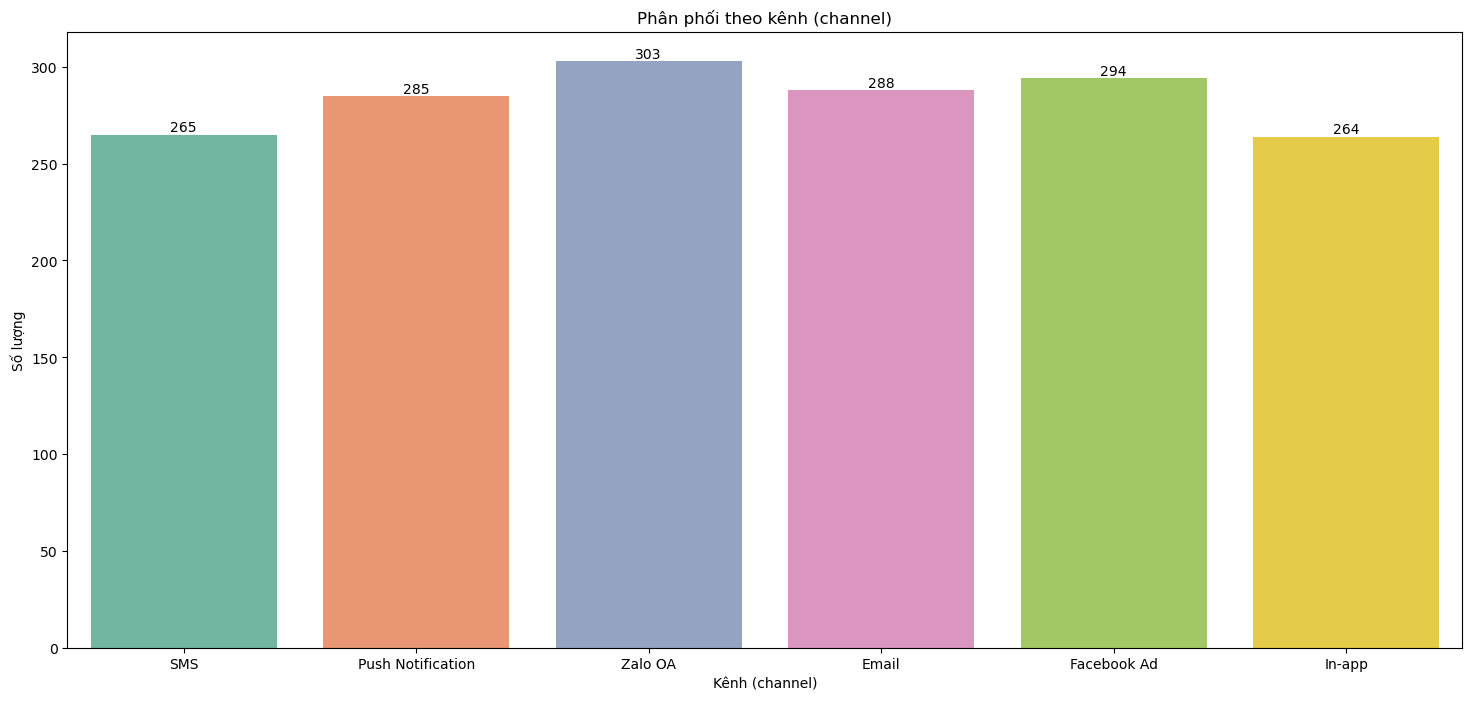

In [68]:
plt.figure(figsize=(18, 8))

# Biểu đồ : Đếm số lượng theo channel để tìm Dữ liệu không hợp lệ
plt.subplot(1, 1, 1)
ax11 = sns.countplot(data=marketing_touchpoints_data, x='channel', palette='Set2')
plt.title('Phân phối theo kênh (channel)')
plt.xlabel('Kênh (channel)')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax11.containers:
    ax11.bar_label(container)

Vì số lượng missing value là 101 và các phân phối của các kênh là khá đều nhau nên sẽ fill constant là 'Khác' vào các giá trị missing value này.

In [69]:
marketing_touchpoints_data['channel'] = marketing_touchpoints_data['channel'].fillna('Khác')

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\2030534165.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax11 = sns.countplot(data=marketing_touchpoints_data, x='channel', palette='Set2')


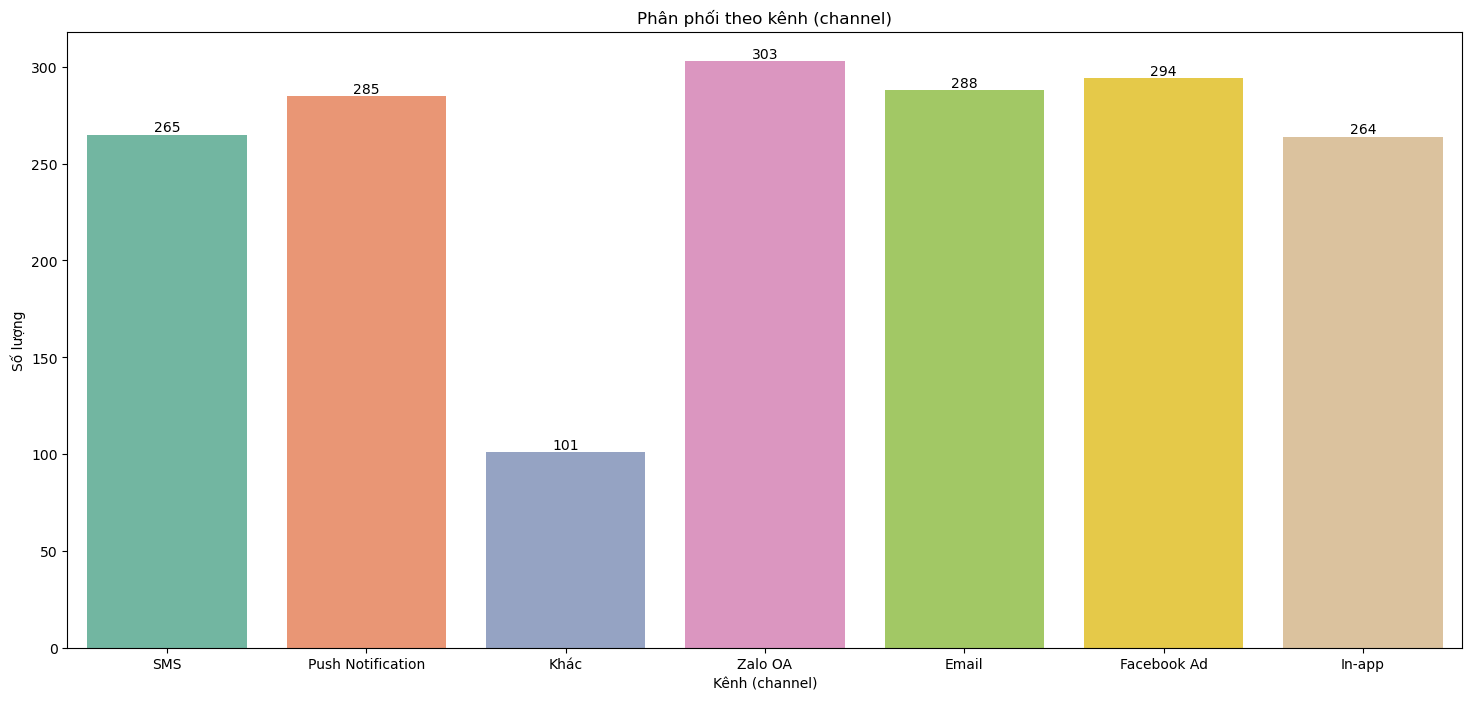

In [70]:
plt.figure(figsize=(18, 8))

#Hiển thị lại biểu đồ sau khi xử lý
plt.subplot(1, 1, 1)
ax11 = sns.countplot(data=marketing_touchpoints_data, x='channel', palette='Set2')
plt.title('Phân phối theo kênh (channel)')
plt.xlabel('Kênh (channel)')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax11.containers:
    ax11.bar_label(container)

EDA + Data cleaning cho cột is_opened và is_clicked

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\3620173022.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax12 = sns.countplot(data=marketing_touchpoints_data, x='is_opened', palette='Set2')


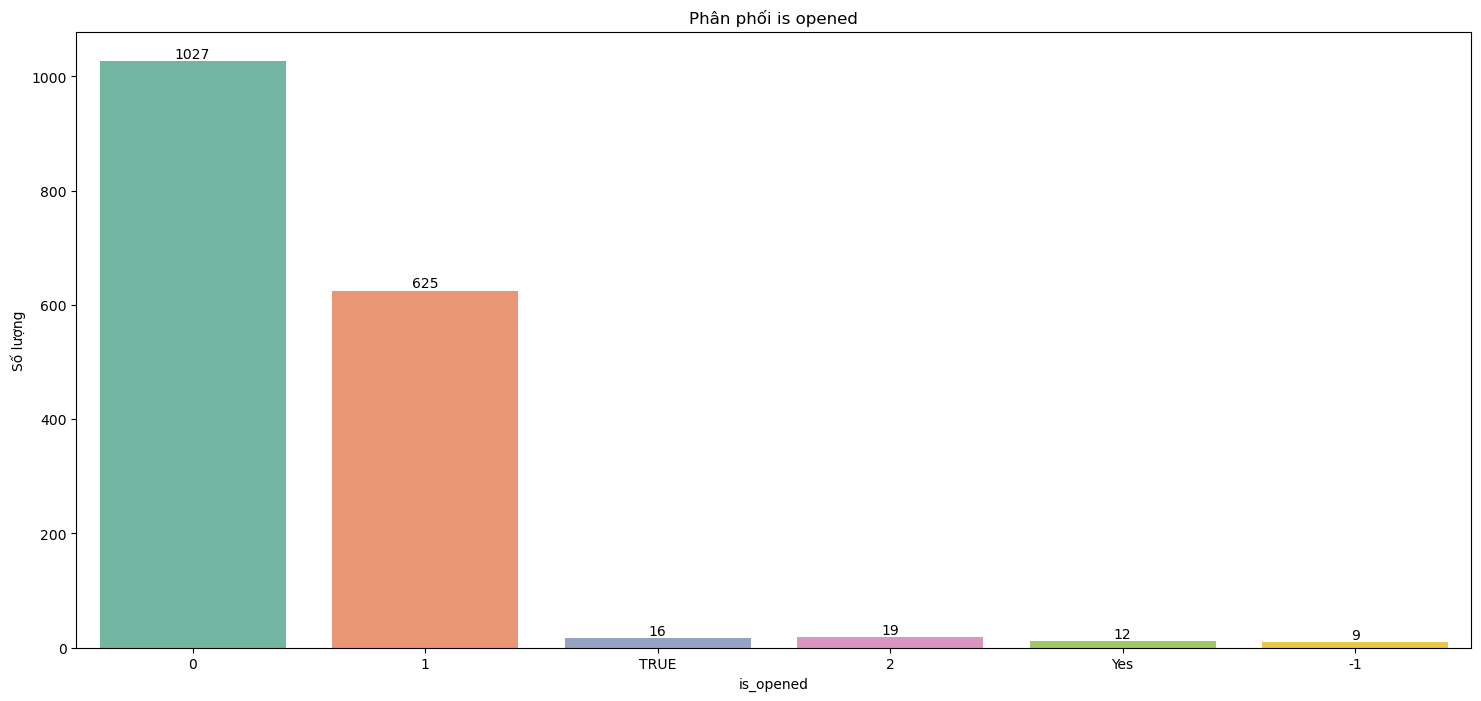

In [71]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 1, 1)
ax12 = sns.countplot(data=marketing_touchpoints_data, x='is_opened', palette='Set2')
plt.title('Phân phối is opened')
plt.xlabel('is_opened')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax12.containers:
    ax12.bar_label(container)

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\330949605.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax13 = sns.countplot(data=marketing_touchpoints_data, x='is_clicked', palette='Set2')


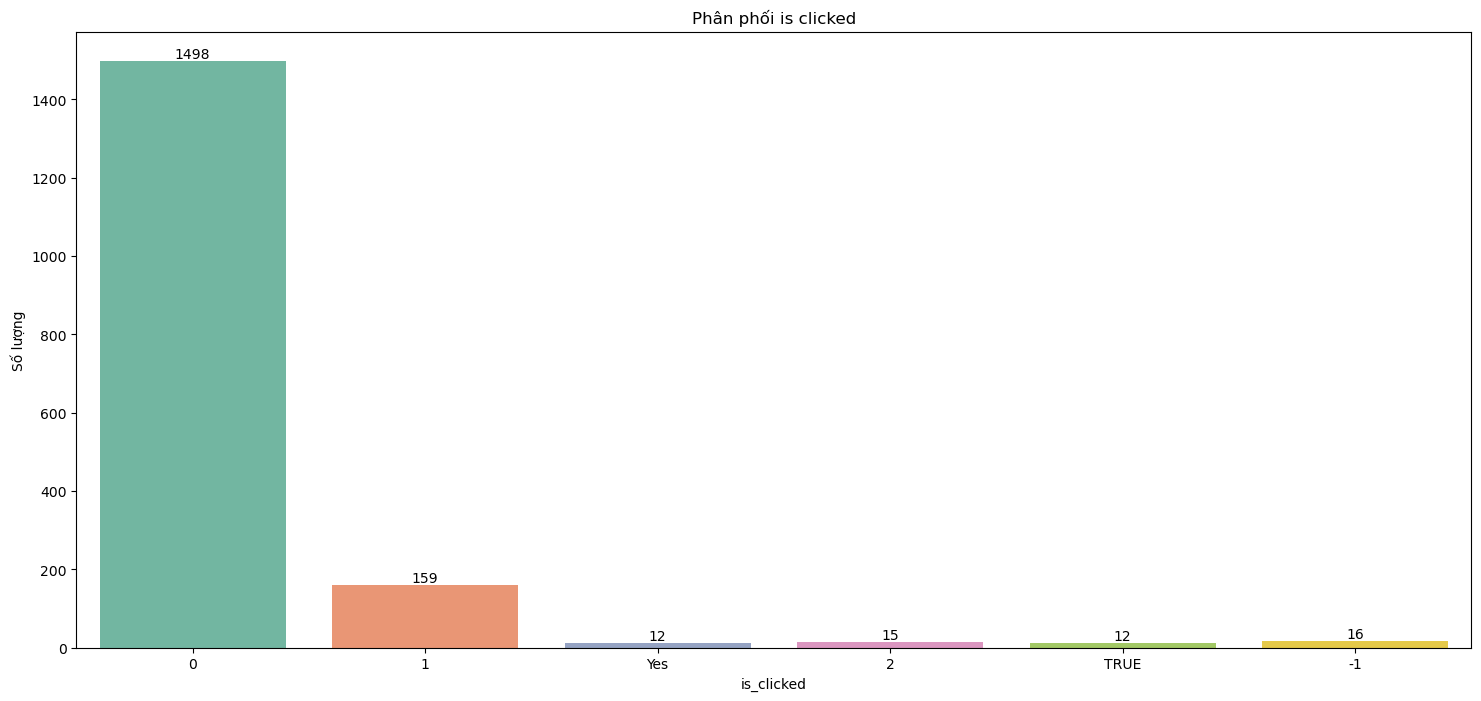

In [72]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 1, 1)
ax13 = sns.countplot(data=marketing_touchpoints_data, x='is_clicked', palette='Set2')
plt.title('Phân phối is clicked')
plt.xlabel('is_clicked')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax13.containers:
    ax13.bar_label(container)

Các giá trị missing value mặc định sẽ là không khi chưa thực hiện hành động clicked hay opened, đưa các giá trị về 2 loại là 1 - True và 0 - False tùy thuộc vào giá trị của nó.

In [73]:
# 1. Tạo từ điển ánh xạ các giá trị bẩn thành 1 và 0
mapping_dict_true = ['TRUE', 'YES']
mapping_dict_false = ['-1', '2']

for col in ['is_opened', 'is_clicked']:
    # Đưa các giá trị về chuẩn 1 / 0
    marketing_touchpoints_data.loc[marketing_touchpoints_data[col].isin(mapping_dict_true), col] = '1'
    marketing_touchpoints_data.loc[marketing_touchpoints_data[col].isin(mapping_dict_false), col] = '0'
    
    # 2. Điền các giá trị missing (NaN) bằng 0
    marketing_touchpoints_data[col] = marketing_touchpoints_data[col].fillna(0)
    
    # 3. Ép kiểu về số nguyên (int) cho sạch dữ liệu
    # Dùng errors='ignore' để phòng trường hợp còn sót chuỗi lạ chưa map hết
    marketing_touchpoints_data[col] = pd.to_numeric(marketing_touchpoints_data[col], errors='coerce').fillna(0).astype(int)

# Kiểm tra lại phân phối sau khi làm sạch
print("--- Phân phối sau khi làm sạch ---")
print("is_opened:\n", marketing_touchpoints_data['is_opened'].value_counts())
print("\nis_clicked:\n", marketing_touchpoints_data['is_clicked'].value_counts())

--- Phân phối sau khi làm sạch ---
is_opened:
 is_opened
0    1159
1     641
Name: count, dtype: int64

is_clicked:
 is_clicked
0    1629
1     171
Name: count, dtype: int64


Vẽ lại phân phối sau khi đã xử lý xong

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\959731092.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax12 = sns.countplot(data=marketing_touchpoints_data, x='is_opened', palette='Set2')


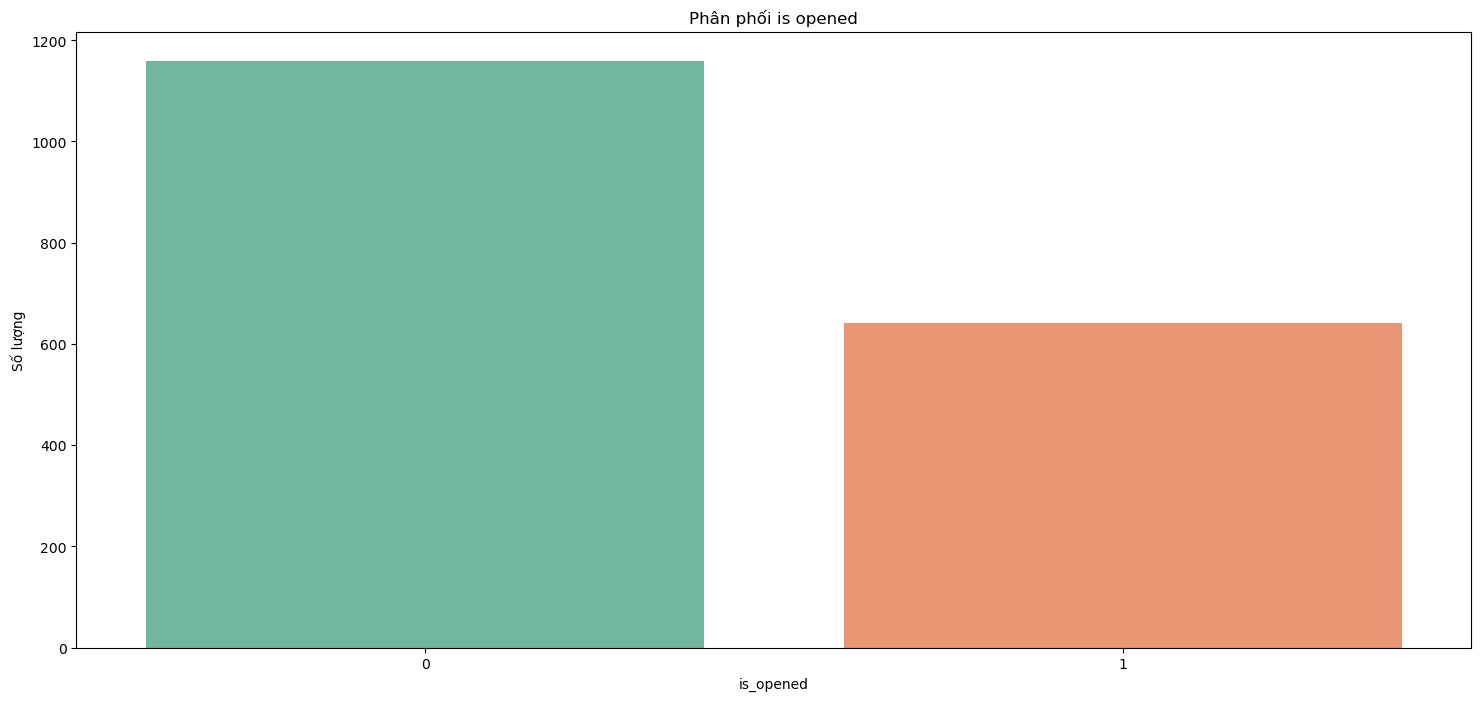

In [74]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 1, 1)
ax12 = sns.countplot(data=marketing_touchpoints_data, x='is_opened', palette='Set2')
plt.title('Phân phối is opened')
plt.xlabel('is_opened')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax12.containers:
    ax13.bar_label(container)

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\330949605.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax13 = sns.countplot(data=marketing_touchpoints_data, x='is_clicked', palette='Set2')


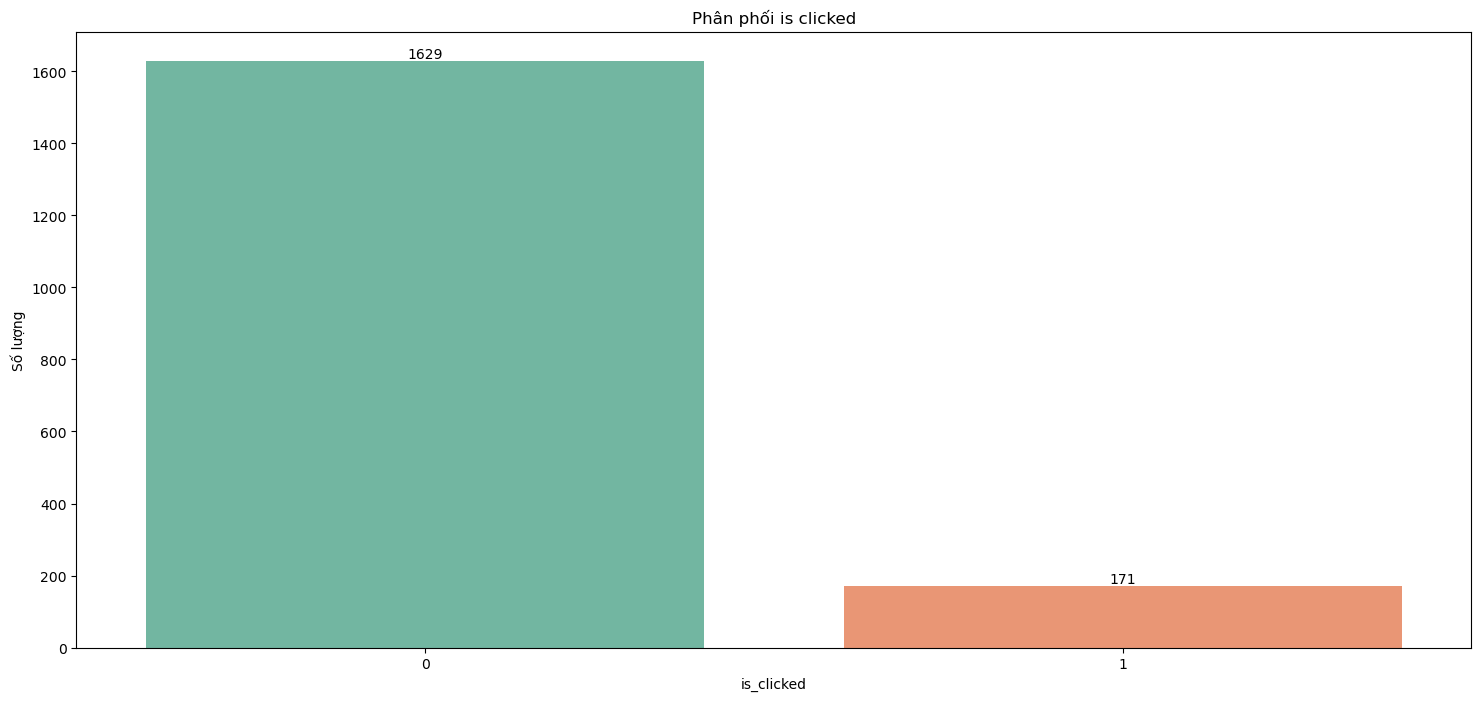

In [75]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 1, 1)
ax13 = sns.countplot(data=marketing_touchpoints_data, x='is_clicked', palette='Set2')
plt.title('Phân phối is clicked')
plt.xlabel('is_clicked')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax13.containers:
    ax13.bar_label(container)

In [76]:
marketing_touchpoints_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   campaign_id    1800 non-null   str           
 1   customer_id    1800 non-null   str           
 2   sent_date      1800 non-null   datetime64[us]
 3   channel        1800 non-null   str           
 4   campaign_type  1800 non-null   str           
 5   is_opened      1800 non-null   int64         
 6   is_clicked     1800 non-null   int64         
 7   offer_value    1707 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 112.6 KB


EDA + Data cleaning offer_value

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\2628262654.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax14 = sns.countplot(data=marketing_touchpoints_data, x='offer_value', palette='Set2')


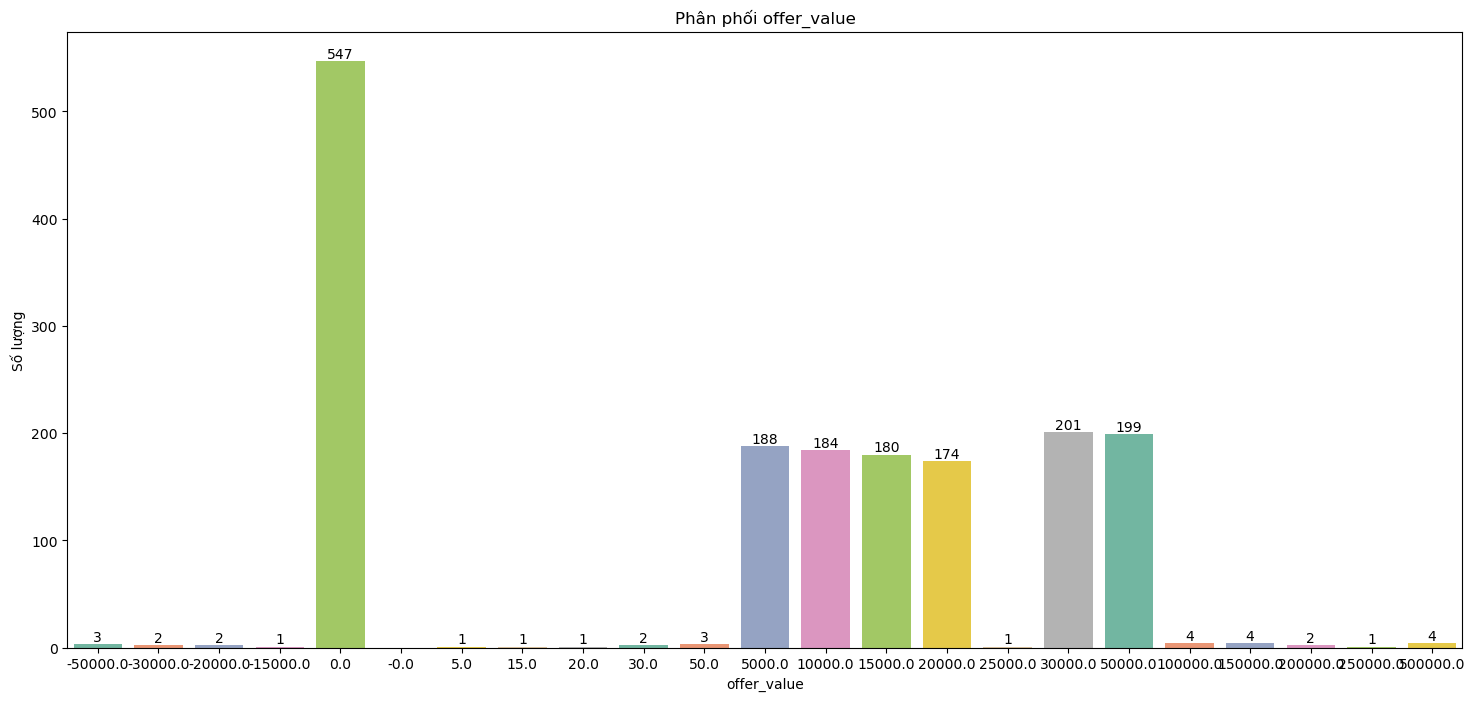

In [77]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 1, 1)
ax14 = sns.countplot(data=marketing_touchpoints_data, x='offer_value', palette='Set2')
plt.title('Phân phối offer_value')
plt.xlabel('offer_value')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax14.containers:
    ax14.bar_label(container)

Lấy trị tuyệt đối các giá trị âm, điền các missing value là 0.0 vì không có ưu đãi

In [78]:
import pandas as pd

# 1. Ép kiểu về dạng số (float), các giá trị chữ/lỗi định dạng thành NaN
marketing_touchpoints_data['offer_value'] = pd.to_numeric(marketing_touchpoints_data['offer_value'], errors='coerce')

# 2. Xử lý giá trị âm bằng cách lấy trị tuyệt đối (.abs())
marketing_touchpoints_data['offer_value'] = marketing_touchpoints_data['offer_value'].abs()

# 3. Điền các giá trị missing/NaN (cũ + mới do ép kiểu) bằng 0.0
marketing_touchpoints_data['offer_value'] = marketing_touchpoints_data['offer_value'].fillna(0.0)

# Kiểm tra lại
print("--- Kiểm tra sau khi xử lý ---")
print(f"Số lượng missing: {marketing_touchpoints_data['offer_value'].isna().sum()}")
print(f"Số lượng giá trị âm: {(marketing_touchpoints_data['offer_value'] < 0).sum()}")
print(marketing_touchpoints_data['offer_value'].describe())

--- Kiểm tra sau khi xử lý ---
Số lượng missing: 0
Số lượng giá trị âm: 0
count      1800.000000
mean      16044.583333
std       30116.306252
min           0.000000
25%           0.000000
50%       10000.000000
75%       20000.000000
max      500000.000000
Name: offer_value, dtype: float64


C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\2628262654.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax14 = sns.countplot(data=marketing_touchpoints_data, x='offer_value', palette='Set2')


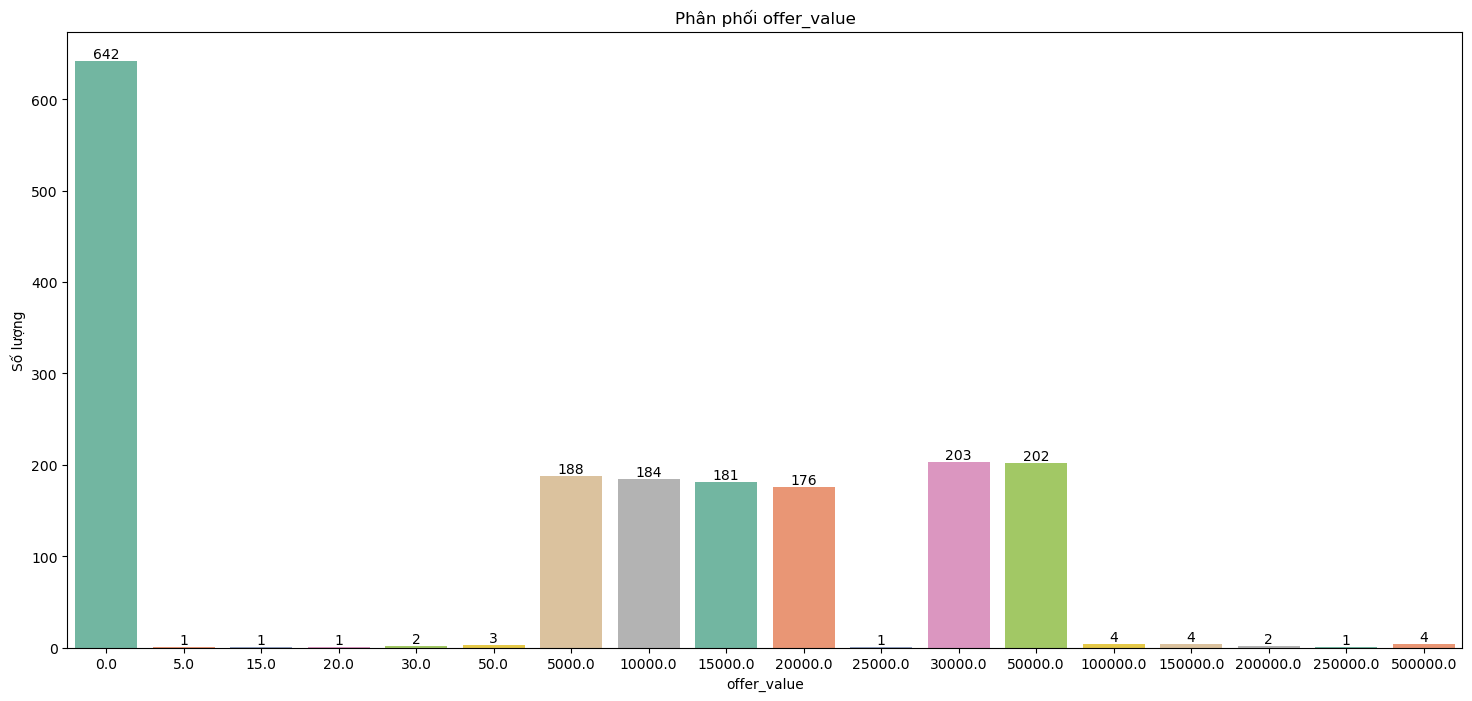

In [79]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 1, 1)
ax14 = sns.countplot(data=marketing_touchpoints_data, x='offer_value', palette='Set2')
plt.title('Phân phối offer_value')
plt.xlabel('offer_value')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax14.containers:
    ax14.bar_label(container)

In [80]:
marketing_touchpoints_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   campaign_id    1800 non-null   str           
 1   customer_id    1800 non-null   str           
 2   sent_date      1800 non-null   datetime64[us]
 3   channel        1800 non-null   str           
 4   campaign_type  1800 non-null   str           
 5   is_opened      1800 non-null   int64         
 6   is_clicked     1800 non-null   int64         
 7   offer_value    1800 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 112.6 KB


Transaction items

EDA + Data cleaning cho từng cột transaction items

Kiểm tra tổng quát

In [81]:
transaction_items_data = pd.read_csv('./data/transaction_items.csv')
transaction_items_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7740 entries, 0 to 7739
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  7740 non-null   str    
 1   product_id      7740 non-null   str    
 2   quantity        7357 non-null   float64
 3   unit_price      7344 non-null   float64
dtypes: float64(2), str(2)
memory usage: 242.0 KB


In [82]:
transaction_items_data.isna().sum()

transaction_id      0
product_id          0
quantity          383
unit_price        396
dtype: int64

EDA + Data cleaning cho cột quantity và unit_price

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\4113445929.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax15 = sns.countplot(data=transaction_items_data, x='quantity', palette='Set2')


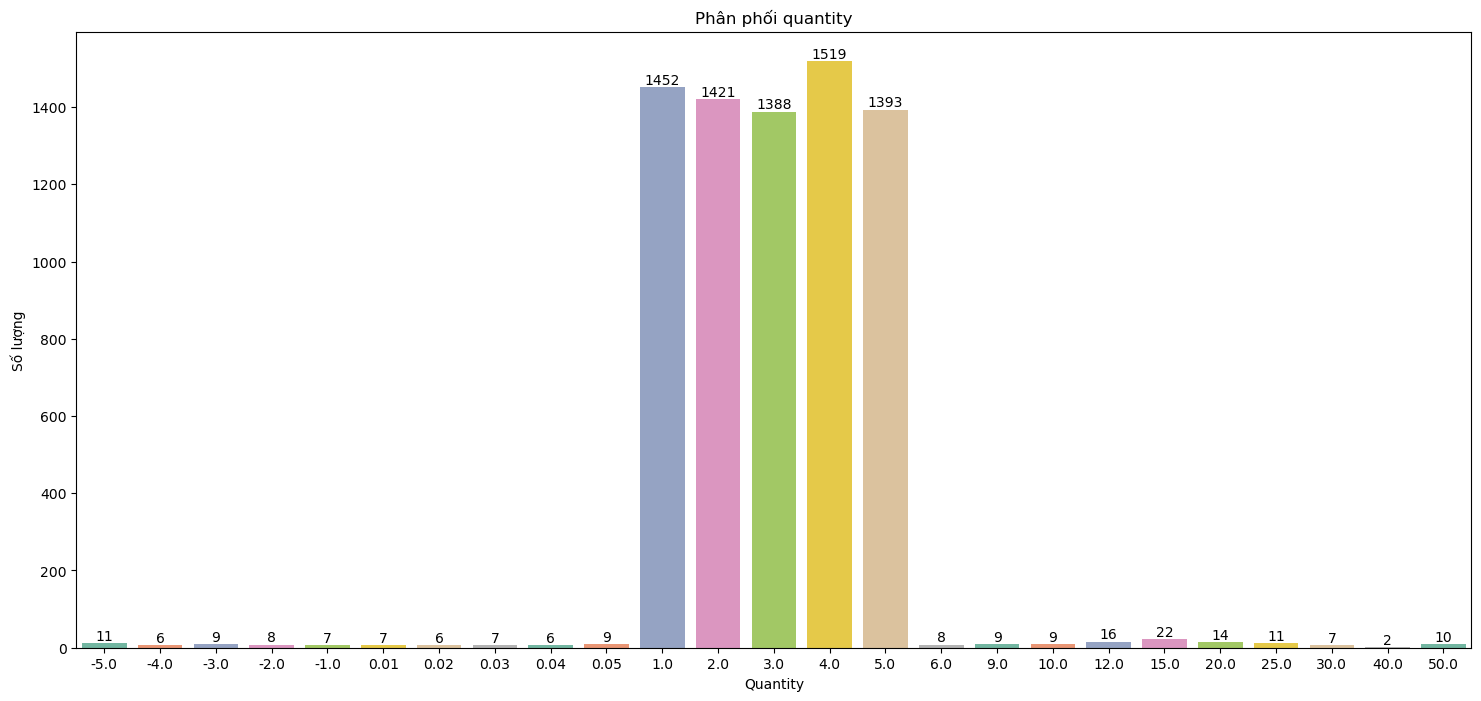

In [83]:
plt.figure(figsize=(18, 8))

# Biểu đồ : Đếm số lượng theo quantity để tìm Dữ liệu không hợp lệ
plt.subplot(1, 1, 1)
ax15 = sns.countplot(data=transaction_items_data, x='quantity', palette='Set2')
plt.title('Phân phối quantity')
plt.xlabel('Quantity')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax15.containers:
    ax15.bar_label(container)

Dựa trên phân phối của quantity thì số lượng lớn tập trung chủ yếu ở các giá trị từ 1 đến 5 và các giá trị lỗi số âm, số thập phân chiếm số lượng nhỏ so với số liệu hợp lệ. Nên cách xử lý tốt ở đây sẽ đưa các giá trị lỗi về NaN và fill bằng mode

In [84]:
# 1. Tạo một bộ lọc (mask) để tìm ra các giá trị HỢP LỆ (lớn hơn 0 VÀ là số nguyên)
# Điều kiện % 1 == 0 dùng để kiểm tra một số có phải số nguyên không (vd: 1.0 % 1 = 0, nhưng 1.5 % 1 = 0.5)
valid_mask = (transaction_items_data['quantity'] > 0) & (transaction_items_data['quantity'] % 1 == 0)

# 2. Tìm Mode CHỈ trên tập dữ liệu hợp lệ
# Nhìn biểu đồ thì mode có khả năng cao là 4
clean_mode = transaction_items_data.loc[valid_mask, 'quantity'].mode()[0]

# 3. Ghi đè toàn bộ dữ liệu KHÔNG hợp lệ (âm, thập phân) bằng NaN
# Dấu ~ biểu thị cho "phủ định" của valid_mask
transaction_items_data.loc[~valid_mask, 'quantity'] = np.nan

# 4. Fill toàn bộ NaN (bao gồm 383 dòng null gốc và các dòng vừa bị ép thành nan) bằng clean_mode
transaction_items_data['quantity'] = transaction_items_data['quantity'].fillna(clean_mode)

# 5. Ép kiểu về số nguyên để loại bỏ hoàn toàn phần thập phân
transaction_items_data['quantity'] = transaction_items_data['quantity'].astype(int)

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\4113445929.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax15 = sns.countplot(data=transaction_items_data, x='quantity', palette='Set2')


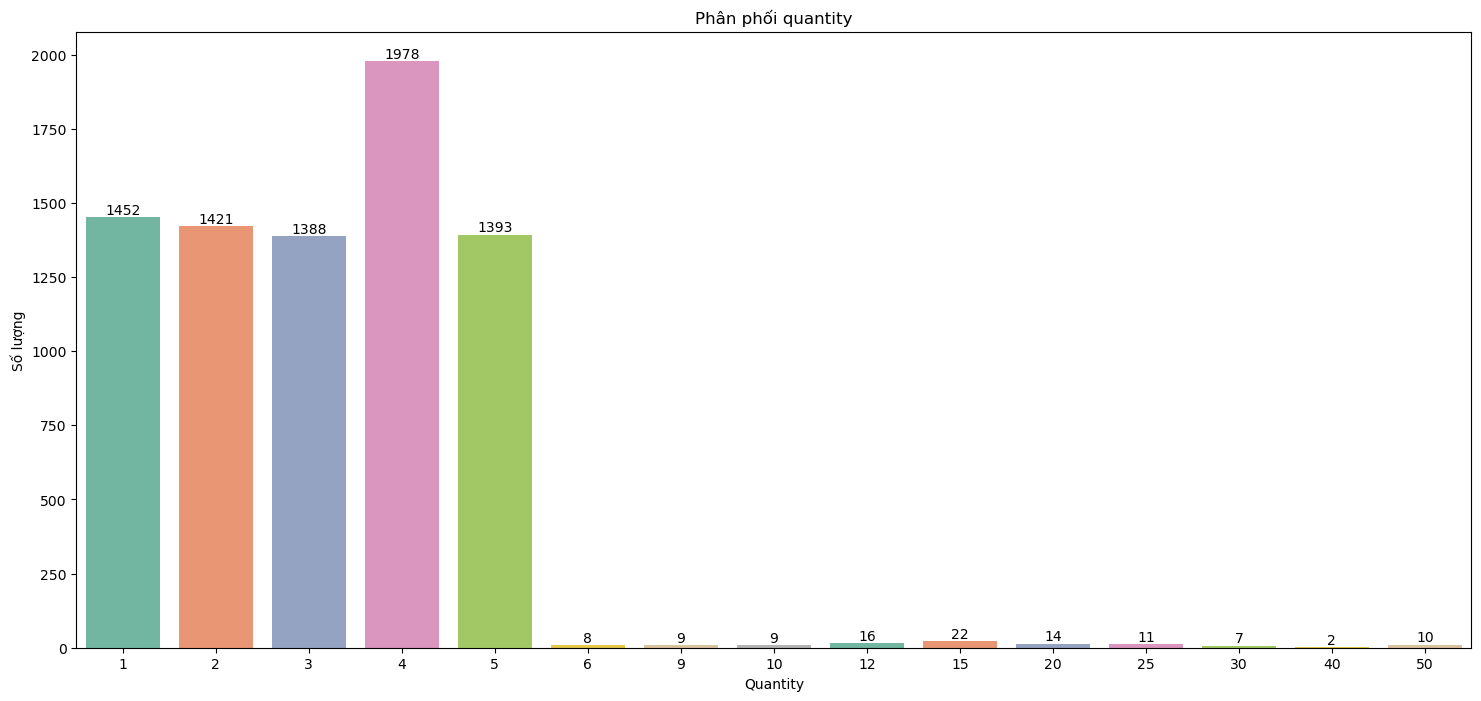

In [85]:
plt.figure(figsize=(18, 8))

# Biểu đồ : Đếm số lượng theo quantity để tìm Dữ liệu không hợp lệ
plt.subplot(1, 1, 1)
ax15 = sns.countplot(data=transaction_items_data, x='quantity', palette='Set2')
plt.title('Phân phối quantity')
plt.xlabel('Quantity')
plt.ylabel('Số lượng')
# Hiển thị số lượng cụ thể trên biểu đồ
for container in ax15.containers:
    ax15.bar_label(container)

In [86]:
transaction_items_data.describe()

,quantity,unit_price
count,7740.000000,7.344000e+03
mean,3.284367,2.957285e+06
std,2.755373,4.870093e+06
min,1.000000,6.000000e+03
25%,2.000000,3.390000e+05
50%,3.000000,1.134000e+06
75%,4.000000,2.705000e+06
max,50.000000,2.808900e+07


Số lượng đơn giá âm trước khi xử lý: 0
Giới hạn IQR hợp lệ: Từ -3210000.0 đến 6254000.0
Số lượng Outlier theo IQR: 965


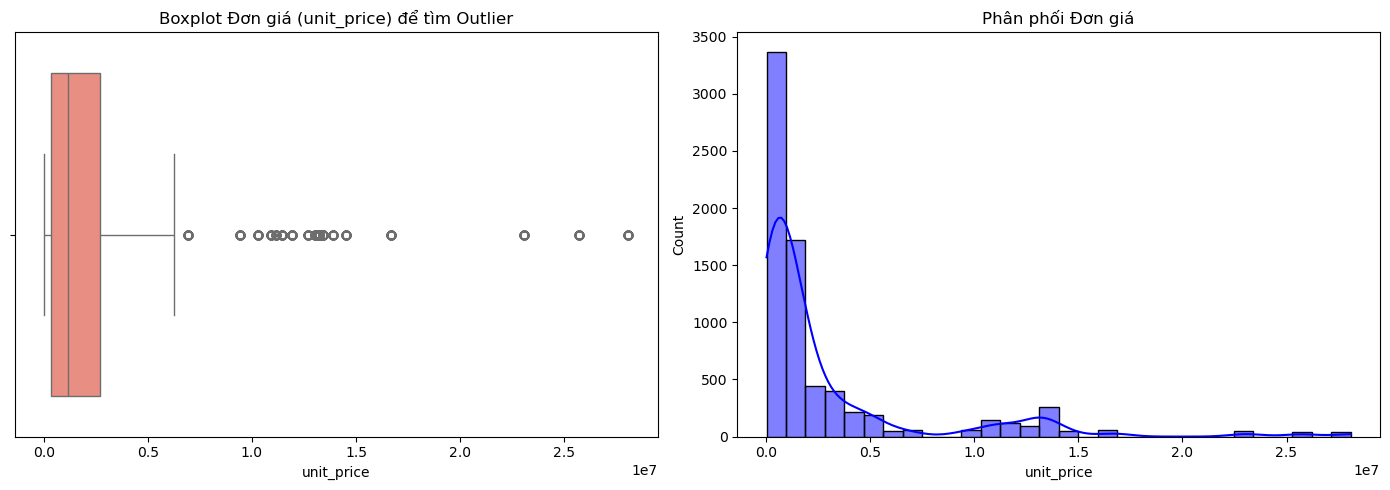

In [87]:
# 1. Ép kiểu về số, các giá trị lỗi sẽ thành NaN
transaction_items_data['unit_price'] = pd.to_numeric(transaction_items_data['unit_price'], errors='coerce')

# 2. Kiểm tra và xử lý giá trị âm
negative_prices = transaction_items_data[transaction_items_data['unit_price'] < 0]
print(f"Số lượng đơn giá âm trước khi xử lý: {len(negative_prices)}")
if len(negative_prices) > 0:
    # Lấy trị tuyệt đối (.abs()) để biến số âm thành số dương
    transaction_items_data['unit_price'] = transaction_items_data['unit_price'].abs()

# 3. Tìm Outliers bằng IQR
valid_prices = transaction_items_data['unit_price'].dropna()
Q1 = valid_prices.quantile(0.25)
Q3 = valid_prices.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_prices = valid_prices[(valid_prices < lower_bound) | (valid_prices > upper_bound)]
print(f"Giới hạn IQR hợp lệ: Từ {lower_bound} đến {upper_bound}")
print(f"Số lượng Outlier theo IQR: {len(outlier_prices)}")

# 4. Trực quan hóa
plt.figure(figsize=(14, 5))

# Biểu đồ Boxplot để xem Outlier trực quan
plt.subplot(1, 2, 1)
sns.boxplot(x=transaction_items_data['unit_price'], color='salmon')
plt.title('Boxplot Đơn giá (unit_price) để tìm Outlier')

# Biểu đồ phân phối Histplot (phù hợp với dữ liệu giá hơn là countplot)
plt.subplot(1, 2, 2)
sns.histplot(transaction_items_data['unit_price'], bins=30, kde=True, color='blue')
plt.title('Phân phối Đơn giá')

plt.tight_layout()
plt.show()

Xử lý giá trị unit_price bằng cách dử dụng base_price trong bảng product vì cả hai đều là giá tính trên một đơn vị cho một mặt hàng, bình thường không có các phí thêm hay chính sách khuyến mãi thì hai giá trị này là một. Đưa cột base_price từ product sang bảng transaction_id dựa trên product_id và điền các giá trị thiếu.

In [88]:
transaction_items_data = transaction_items_data.merge(product_data[['product_id', 'base_price']], 
                          on='product_id', 
                          how='left')

# Dùng base_price để lấp đầy (fillna) các ô bị null trong unit_price
transaction_items_data['unit_price'] = transaction_items_data['unit_price'].fillna(transaction_items_data['base_price'])

# Xóa cột base_price sau khi đã xử lý xong
transaction_items_data = transaction_items_data.drop(columns=['base_price'])

In [89]:
transaction_items_data['unit_price'].isna().sum()

np.int64(0)

Dựa theo biểu đồ box plot và histogram thì các giá trị unit_price bị lệch khá nặng, nên có thể dụng log transform để biến đổi nhằm tối ưu hóa trong quá trình cập nhật weight của mô hình.

In [90]:
transaction_items_data['unit_price'] = np.log1p(transaction_items_data['unit_price'])

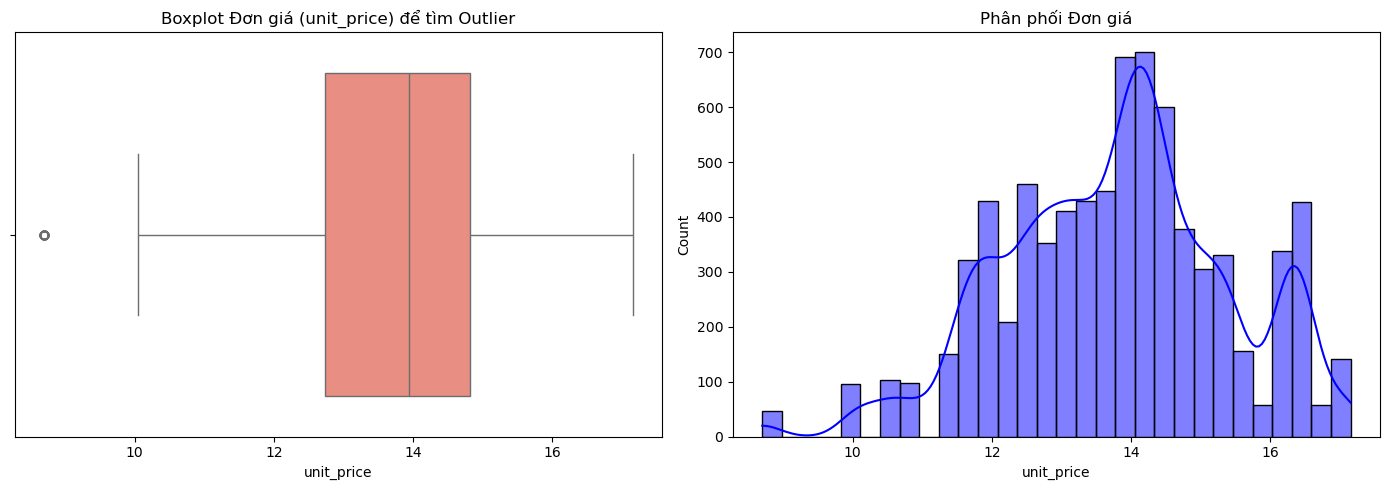

In [91]:
# 4. Trực quan hóa
plt.figure(figsize=(14, 5))

# Biểu đồ Boxplot để xem Outlier trực quan
plt.subplot(1, 2, 1)
sns.boxplot(x=transaction_items_data['unit_price'], color='salmon')
plt.title('Boxplot Đơn giá (unit_price) để tìm Outlier')

# Biểu đồ phân phối Histplot (phù hợp với dữ liệu giá hơn là countplot)
plt.subplot(1, 2, 2)
sns.histplot(transaction_items_data['unit_price'], bins=30, kde=True, color='blue')
plt.title('Phân phối Đơn giá')

plt.tight_layout()
plt.show()

Tính giá trị total amount và gán vào cột transaction

In [92]:
# =====================================================================
# BƯỚC 3: TÍNH TOÁN VÀ HỢP NHẤT TOTAL_AMOUNT VÀO BẢNG TRANSACTIONS
# =====================================================================

# 3.1 Tính thành tiền cho từng dòng sản phẩm
transaction_items_data['item_total'] = transaction_items_data['quantity'] * transaction_items_data['unit_price']

# 3.2 Gom nhóm (Groupby) theo transaction_id để tính tổng tiền của cả đơn hàng
order_totals = transaction_items_data.groupby('transaction_id')['item_total'].sum().reset_index()

# Đổi tên cột cho dễ hiểu: sub_total = Tổng tiền trước giảm giá
order_totals.rename(columns={'item_total': 'sub_total'}, inplace=True)

# 3.3 Ghép tổng tiền vừa tính được vào bảng transactions chính
transaction_data = transaction_data.merge(order_totals, on='transaction_id', how='left')

# Cú pháp: np.where(điều_kiện, giá_trị_nếu_đúng, giá_trị_nếu_sai)
transaction_data['total_amount'] = np.where(
    transaction_data['discount_applied'] == 0.0, 
    transaction_data['sub_total'],                                          # Giữ nguyên sub_total nếu discount = 0
    transaction_data['sub_total'] * transaction_data['discount_applied']    # Thực hiện phép nhân nếu có discount
)

# Đảm bảo giá trị khong âm (nếu có lỗi nào đó khiến total_amount âm, ta sẽ set về 0)
transaction_data['total_amount'] = transaction_data['total_amount'].apply(lambda x: max(0, x))

# In ra kiểm tra thử 5 dòng đầu tiên
print(transaction_data[['transaction_id', 'sub_total', 'discount_applied', 'total_amount']].head())

  transaction_id   sub_total  discount_applied  total_amount
0        T000001   63.712845              0.20     12.742569
1        T000002  225.263803              0.00    225.263803
2        T000003   29.396903              0.00     29.396903
3        T000004  179.952679              0.15     26.992902
4        T000005  178.150720              0.05      8.907536


Xóa cột sub_total sau khi đã xử tính xong total_amount

In [93]:
transaction_data = transaction_data.drop(columns=['sub_total'])

In [94]:
transaction_data.describe()

,transaction_date,discount_applied,total_amount
count,3500,3500.000000,3500.000000
mean,2025-05-11 05:26:40.457142,0.083914,60.484229
min,2023-06-20 00:00:00,0.000000,0.524565
25%,2024-12-19 18:00:00,0.000000,12.390212
50%,2025-06-24 00:00:00,0.000000,33.968023
75%,2025-11-02 00:00:00,0.150000,87.646792
max,2026-03-25 00:00:00,0.300000,933.405912
std,NaN,0.105167,73.743731


In [95]:
transaction_items_data.head()

,transaction_id,product_id,quantity,unit_price,item_total
0,T000001,P0107,5,12.742569,63.712845
1,T000002,P0028,4,15.357312,61.429248
2,T000002,P0007,10,16.383456,163.834555
3,T000003,P0065,2,14.698452,29.396903
4,T000004,P0092,2,13.814511,27.629022


In [96]:
transaction_data.head()

,transaction_id,customer_id,transaction_date,store_id,payment_method,discount_applied,total_amount
0,T000001,C00301,2025-01-01,S018,Bank Transfer,0.20,12.742569
1,T000002,C00109,2026-01-07,S014,VNPay,0.00,225.263803
2,T000003,C00008,2024-11-29,S007,ZaloPay,0.00,29.396903
3,T000004,C00754,2025-02-26,S010,Cash,0.15,26.992902
4,T000005,C00268,2025-06-29,S023,ZaloPay,0.05,8.907536


Sau khi đã tính xong total_amount ở cột transaction rồi, thì sẽ ghép bảng.


Ghép 6 bảng ngoại trừ marketingtouch_points

Nếu ghép tất cả trực tiếp thì dữ liệu sẽ bị phình to nên để đảm bảo dữ liệu không bị phình quá lớn thì sẽ gom nhóm trước sau đó sẽ phép các bảng sau.

Transaction_items + products

In [97]:
#Ghép để lấy thông tin sản phẩm
df_item_prod = pd.merge(transaction_items_data, product_data, on='product_id', how='inner')

In [98]:
df_item_prod.head()

,transaction_id,product_id,quantity,unit_price,item_total,product_name,category,sub_category,brand,base_price
0,T000001,P0107,5,12.742569,63.712845,Thực phẩm khô_107,Thực phẩm,Thực phẩm khô,TH True,342000.0
1,T000002,P0028,4,15.357312,61.429248,Tablet_28,Điện tử,Tablet,LG,4673000.0
2,T000002,P0007,10,16.383456,163.834555,Laptop_7,Điện tử,Laptop,Samsung,13039000.0
3,T000003,P0065,2,14.698452,29.396903,Nhà bếp_65,Gia dụng,Nhà bếp,Generic,2418000.0
4,T000004,P0092,2,13.814511,27.629022,Trang trí_92,Gia dụng,Trang trí,Local Brand,999000.0


In [99]:
# Gom nhóm theo từng HÓA ĐƠN (transaction_id) để tính tổng số lượng món hàng
order_metrics = df_item_prod.groupby('transaction_id').agg(
    total_items_bought=('quantity', 'sum'),       # Hóa đơn này mua tổng cộng bao nhiêu món?
    unique_product_types=('product_id', 'nunique') # Hóa đơn này có bao nhiêu LOẠI mặt hàng?
).reset_index()

In [100]:
order_metrics.head()

,transaction_id,total_items_bought,unique_product_types
0,T000001,5,1
1,T000002,14,2
2,T000003,2,1
3,T000004,13,4
4,T000005,12,4


Nối bảng Transaction và stores và đưa bảng order_metrics vào bảng transaction

In [101]:
# Ghép order_metrics vào bảng transactions của bạn
df_trans_full = pd.merge(transaction_data, order_metrics, on='transaction_id', how='left')

# Ghép thêm bảng stores để biết đơn hàng ở cửa hàng nào (Dựa trên 'store_id')
df_trans_full = pd.merge(df_trans_full, store_data, on='store_id', how='left')

In [102]:
#Có 4 bảng được sử dụng là transactions, transaction_items, products, stores
df_trans_full.head()

,transaction_id,customer_id,transaction_date,store_id,payment_method,discount_applied,total_amount,total_items_bought,unique_product_types,store_name,city,store_type,opened_date
0,T000001,C00301,2025-01-01,S018,Bank Transfer,0.20,12.742569,5,1,Store_B8,Bắc Ninh,offline,2020-06-10
1,T000002,C00109,2026-01-07,S014,VNPay,0.00,225.263803,14,2,Store_B4,Nha Trang,online,2020-07-08
2,T000003,C00008,2024-11-29,S007,ZaloPay,0.00,29.396903,2,1,Store_A7,Hà Nội,online,2020-03-06
3,T000004,C00754,2025-02-26,S010,Cash,0.15,26.992902,13,4,Store_B0,Huế,offline,2021-03-27
4,T000005,C00268,2025-06-29,S023,ZaloPay,0.05,8.907536,12,4,Store_C3,Nha Trang,offline,2020-07-25


Gom nhóm theo Customer (customer_id), để xác định tổng chi tiêu, tổng số đơn hàng, tổng số sản phẩm đã mua, số của hàng đã ghé.

In [103]:
customer_sales_metrics = df_trans_full.groupby('customer_id').agg(
    total_spend=('total_amount', 'sum'),           # Tổng chi tiêu
    total_orders=('transaction_id', 'count'),      # Tổng số đơn hàng
    total_items=('total_items_bought', 'sum'),     # Tổng số sản phẩm đã mua
    unique_stores=('store_id', 'nunique')          # Số cửa hàng đã ghé
).reset_index()

In [104]:
customer_sales_metrics.head()

,customer_id,total_spend,total_orders,total_items,unique_stores
0,C00001,447.929626,10,47,6
1,C00002,1003.660485,12,90,9
2,C00003,503.514828,13,62,11
3,C00004,212.133606,6,48,6
4,C00005,641.336739,10,67,9


Ghép với 2 bảng customer và customer_support

In [105]:
#Gom nhóm để đếm số lần khách hàng phải gọi hỗ trợ / khiếu nại
customer_support_metrics = customer_support_data.groupby('customer_id').agg(
    total_tickets=('ticket_id', 'count')           # Số lần mở ticket
).reset_index()

In [106]:
#Ráp dữ liệu mua sắm vào khách hàng gốc (LEFT JOIN)
df_master = pd.merge(customer_data, customer_sales_metrics, on='customer_id', how='left')

# Ráp dữ liệu khiếu nại (LEFT JOIN)
df_master = pd.merge(df_master, customer_support_metrics, on='customer_id', how='left')

df_master.head()

,customer_id,gender,birth_year,city,registration_date,acquisition_channel,total_spend,total_orders,total_items,unique_stores,total_tickets
0,C00001,F,1979,Hải Phòng,2024-05-24,Facebook,447.929626,10.0,47.0,6.0,NaN
1,C00002,M,1990,Biên Hòa,2025-04-06,Referral,1003.660485,12.0,90.0,9.0,NaN
2,C00003,F,1987,Khác,2023-08-11,Shopee,503.514828,13.0,62.0,11.0,1.0
3,C00004,F,1966,TP.HCM,2025-04-26,Referral,212.133606,6.0,48.0,6.0,3.0
4,C00005,F,1967,TP.HCM,2024-01-15,Shopee,641.336739,10.0,67.0,9.0,3.0


In [107]:
df_master.isna().sum()

customer_id              0
gender                   0
birth_year               0
city                     0
registration_date        0
acquisition_channel      0
total_spend             49
total_orders            49
total_items             49
unique_stores           49
total_tickets          352
dtype: int64

In [108]:
# Xử lý Null cho khách chưa mua/chưa khiếu nại
cols_to_fill = ['total_spend', 'total_orders', 'total_items', 'unique_stores', 'total_tickets']
df_master[cols_to_fill] = df_master[cols_to_fill].fillna(0)

In [109]:
df_master.isna().sum()

customer_id            0
gender                 0
birth_year             0
city                   0
registration_date      0
acquisition_channel    0
total_spend            0
total_orders           0
total_items            0
unique_stores          0
total_tickets          0
dtype: int64

In [110]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          800 non-null    str           
 1   gender               800 non-null    str           
 2   birth_year           800 non-null    int64         
 3   city                 800 non-null    str           
 4   registration_date    800 non-null    datetime64[us]
 5   acquisition_channel  800 non-null    str           
 6   total_spend          800 non-null    float64       
 7   total_orders         800 non-null    float64       
 8   total_items          800 non-null    float64       
 9   unique_stores        800 non-null    float64       
 10  total_tickets        800 non-null    float64       
dtypes: datetime64[us](1), float64(5), int64(1), str(4)
memory usage: 68.9 KB


In [111]:
# lưu file đã làm sạch .csv
#df_master.to_csv('./data/df_master.csv', index=False)

FEATURE ENGINEERING

Phân loại hành vi mua sắm dựa trên tần xuất và giá trị

In [112]:
transaction_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    3500 non-null   str           
 1   customer_id       3500 non-null   str           
 2   transaction_date  3500 non-null   datetime64[us]
 3   store_id          3500 non-null   str           
 4   payment_method    3500 non-null   str           
 5   discount_applied  3500 non-null   float64       
 6   total_amount      3500 non-null   float64       
dtypes: datetime64[us](1), float64(2), str(4)
memory usage: 191.5 KB


In [113]:
# Giả định ngày hiện tại là ngày cuối cùng trong dữ liệu + 1 ngày tránh việc khách hàng mua vào ngày cuối cùng sẽ có recency = 0, 
# không phân biệt được với khách hàng chưa mua bao giờ (recency = NaN)
current_date = transaction_data['transaction_date'].max() + pd.Timedelta(days=1)

rfm = transaction_data.groupby('customer_id').agg({
    'transaction_date': lambda x: (current_date - x.max()).days, # Recency
    'transaction_id': 'count',                                   # Frequency
    'total_amount': 'sum'                                        # Monetary
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

Hành vi mua sắm

In [114]:
# Chuẩn bị bảng chi tiết: Transactions + Items + Products + Stores
df_purchase_detail = transaction_data.merge(transaction_items_data, on='transaction_id') \
                                    .merge(product_data, on='product_id') \
                                    .merge(store_data, on='store_id')

# Tính toán các đặc trưng
purchase_behavior = df_purchase_detail.groupby('customer_id').agg({
    'category': 'nunique',                # Số lượng category đã mua
    'brand': lambda x: x.mode()[0] if not x.mode().empty else "Unknown", # Brand yêu thích nhất
    'total_amount': 'mean',               # Giá trị đơn hàng trung bình (Avg Price/AOV)
    'discount_applied': lambda x: (x > 0).mean(), # Tỷ lệ đơn hàng có dùng giảm giá
    'store_type': lambda x: x.mode()[0] if not x.mode().empty else "Unknown" # Kênh mua chủ yếu (Online/Offline)
}).reset_index()

purchase_behavior.columns = ['customer_id', 'num_categories', 'fav_brand', 'avg_order_value', 'discount_rate', 'preferred_channel']

Từ customer support

In [115]:
support_features = customer_support_data.groupby('customer_id').agg({
    'ticket_id': 'count',                                         # Số lượng ticket
    'resolution_status': lambda x: (x == 'resolved').mean(),      # Tỷ lệ đã xử lý xong
    'satisfaction_score': 'mean'                                  # Điểm hài lòng trung bình
}).reset_index()

support_features.columns = ['customer_id', 'total_tickets', 'resolved_rate', 'avg_satisfaction']

Từ marketing

In [116]:
marketing_features = marketing_touchpoints_data.groupby('customer_id').agg({
    'is_opened': 'mean',       # Tỷ lệ mở mail/tin nhắn
    'is_clicked': 'mean',      # Tỷ lệ click vào link
    'campaign_id': 'nunique',  # Số lượng chiến dịch đã tiếp cận
    'offer_value': 'sum'       # Tổng giá trị ưu đãi đã nhận
}).reset_index()

marketing_features.columns = ['customer_id', 'open_rate', 'click_rate', 'num_campaigns', 'total_offer_value']

Thời gian

In [117]:
# 5.1 Ngày trong tuần và Tháng hay mua nhất
transaction_data['day_of_week'] = transaction_data['transaction_date'].dt.day_name()
transaction_data['month'] = transaction_data['transaction_date'].dt.month

time_features = transaction_data.groupby('customer_id').agg({
    'day_of_week': lambda x: x.mode()[0], # Thứ hay mua nhất
    'month': lambda x: x.mode()[0]        # Tháng/Mùa hay mua nhất (Seasonality)
}).reset_index()

# 5.2 Inter-purchase interval (Khoảng cách trung bình giữa các lần mua)
def calc_interval(group):
    if len(group) < 2: return 0
    intervals = group.sort_values().diff().dt.days
    return intervals.mean()

intervals = transaction_data.groupby('customer_id')['transaction_date'].apply(calc_interval).reset_index()
intervals.columns = ['customer_id', 'avg_interpurchase_interval']

# Gộp lại
time_features = time_features.merge(intervals, on='customer_id')

Tổng hợp

In [118]:
# Merge tất cả các bảng feature vào customer_data
df_final_features = customer_data[['customer_id']].copy()

feature_dfs = [rfm, purchase_behavior, support_features, marketing_features, time_features]

for df in feature_dfs:
    df_final_features = df_final_features.merge(df, on='customer_id', how='left')

# Xử lý giá trị thiếu (NaN)
# Các cột số học thì điền 0, cột chữ thì điền 'None'
num_cols = df_final_features.select_dtypes(include=[np.number]).columns
df_final_features[num_cols] = df_final_features[num_cols].fillna(0)

str_cols = df_final_features.select_dtypes(include=['object']).columns
df_final_features[str_cols] = df_final_features[str_cols].fillna('None')

# Xuất kết quả
# df_final_features.to_csv('./clean data/Final_Features_For_Model.csv', index=False)
# print("Đã tạo xong bộ feature mạnh mẽ với đầy đủ 5 tiêu chí!")

C:\Users\HOME\AppData\Local\Temp\ipykernel_24476\1735678305.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df_final_features.select_dtypes(include=['object']).columns


Xây dựng Target_label - Bài toán classification là will_return_within_30_days

Sử dụng ngày mua cuối cùng và ngày mua kề cuối làm cơ sở để xây dựng nhãn. Những khách hàng chỉ mua một lần sẽ. 

Chiến lược giải quyết: Tính số ngày từ lần mua duy nhất đó đến "ngày cuối mà hệ thống ghi nhận giao dịch cuối cùng" (current_system_date).


Trường hợp A: Nếu đã trôi qua hơn 30 ngày mà họ chưa mua lại $\rightarrow$ Gắn nhãn Target = 0 (Họ thực sự đã không quay lại trong 30 ngày).


Trường hợp B: Nếu họ vừa mua cách đây dưới 30 ngày $\rightarrow$ Dữ liệu chưa đủ độ chín để kết luận. Gắn nhãn Target = NaN và loại bỏ (drop) các dòng này khỏi tập huấn luyện để tránh làm nhiễu mô hình.

In [119]:
# transaction_data = pd.read_csv('./clean data/transactions_cleaned.csv')
# df_master = pd.read_csv('./clean data/df_master.csv')

In [120]:
# Đặt N ngày tùy ý (Ví dụ: 30 ngày)
N_DAYS = 30

# 1. Đảm bảo đúng định dạng thời gian và sắp xếp dữ liệu
df_trans = transaction_data.copy()
df_trans['transaction_date'] = pd.to_datetime(df_trans['transaction_date'])
df_sorted = df_trans.sort_values(by=['customer_id', 'transaction_date'])

# 2. Tìm ngày mua cuối và ngày mua áp chót cho từng khách hàng
target_df = df_sorted.groupby('customer_id').agg(
    last_purchase=('transaction_date', 'last'),
    # Lấy giao dịch áp chót (vị trí -2), nếu không có thì trả về NaT (Not a Time)
    prev_purchase=('transaction_date', lambda x: x.iloc[-2] if len(x) >= 2 else pd.NaT),
    total_purchases=('transaction_id', 'count')
).reset_index()

# Tiêu chí 2: Tính days_until_next_purchase
target_df['days_until_next_purchase'] = (target_df['last_purchase'] - target_df['prev_purchase']).dt.days

# Tiêu chí 3: Tính số ngày trôi qua kể từ lần mua duy nhất (đối với khách mua 1 lần)
current_system_date = df_trans['transaction_date'].max() + pd.Timedelta(days=1)
target_df['days_since_only_purchase'] = (current_system_date - target_df['last_purchase']).dt.days

# 3. Hàm gán nhãn Target dựa trên chiến lược đã định
def assign_target(row, n):
    # Khách có mua lặp lại
    if row['total_purchases'] > 1:
        if row['days_until_next_purchase'] <= n:
            return 1 # Có quay lại trong vòng N ngày
        else:
            return 0 # Khoảng cách mua > N ngày
            
    # Khách chỉ mua 1 lần (Censored Data)
    else:
        if row['days_since_only_purchase'] > n:
            return 0 # Đã qua N ngày từ lúc mua 1 lần mà ko quay lại
        else:
            return np.nan # Mới mua gần đây, chưa đủ N ngày để quan sát -> Gắn NaN để xóa sau

target_name = f'will_return_within_{N_DAYS}_days'
target_df[target_name] = target_df.apply(lambda row: assign_target(row, N_DAYS), axis=1)

# 4. Ghép Target Label vào bảng df_master của bạn
df_master = pd.merge(df_master, target_df[['customer_id', 'days_until_next_purchase', target_name]], on='customer_id', how='left')

# 5. Xóa những khách hàng thuộc Trường hợp (Chưa quan sát đủ lâu)
df_master_model = df_master.dropna(subset=[target_name]).copy()

# Ép kiểu nhãn về số nguyên (0 và 1) để đưa vào mô hình học máy
df_master_model[target_name] = df_master_model[target_name].astype(int)

print(f"Số lượng khách hàng trước khi xóa censored: {len(df_master)}")
print(f"Số lượng khách hàng sẵn sàng đưa vào mô hình: {len(df_master_model)}")
print("\nPhân bổ biến mục tiêu:")
print(df_master_model[target_name].value_counts())

Số lượng khách hàng trước khi xóa censored: 800
Số lượng khách hàng sẵn sàng đưa vào mô hình: 750

Phân bổ biến mục tiêu:
will_return_within_30_days
0    609
1    141
Name: count, dtype: int64


Train, Test split

Sắp xếp toàn bộ khách hàng theo mốc thời gian giao dịch của họ (từ cũ đến mới), sau đó chia train 80% và 20% tập là test

Dùng INNER JOIN để chỉ giữ lại những khách hàng có đầy đủ cả Features và Label hợp lệ. khi gộp Features và label với nhau

In [121]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_features = df_final_features.copy()

if 'last_purchase' not in df_master_model.columns:
    df_master_model = pd.merge(df_master_model, target_df[['customer_id', 'last_purchase']], on='customer_id', how='left')

# Chỉ lấy những cột cần thiết từ df_master_model (để tránh rác)
df_labels_and_time = df_master_model[['customer_id', 'will_return_within_30_days', 'last_purchase']]

# 1. GHÉP 2 MẢNH LẠI VỚI NHAU
df_ready_for_ml = pd.merge(df_labels_and_time, df_features, on='customer_id', how='inner')

In [122]:
# 2. SẮP XẾP THEO THỜI GIAN (BẮT BUỘC TRƯỚC KHI SPLIT)
df_ready_for_ml = df_ready_for_ml.sort_values(by='last_purchase', ascending=True).reset_index(drop=True)

# 3. TÁCH BIẾN ĐỘC LẬP (X) VÀ BIẾN MỤC TIÊU (y)
# Xóa các cột không mang tính dự đoán (ID, Ngày tháng, và chính cột Target)
cols_to_drop = ['customer_id', 'last_purchase', 'will_return_within_30_days']
X = df_ready_for_ml.drop(columns=cols_to_drop)

# y chính là đáp án
y = df_ready_for_ml['will_return_within_30_days']

In [123]:
# 4. CHIA TẬP TRAIN VÀ TEST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    shuffle=False # Không xáo trộn
)

print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước X_test: {X_test.shape}")

Kích thước X_train: (600, 18)
Kích thước X_test: (150, 18)


In [124]:
print(y_train.value_counts())
print(y_test.value_counts())

will_return_within_30_days
0    497
1    103
Name: count, dtype: int64
will_return_within_30_days
0    112
1     38
Name: count, dtype: int64


In [125]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   recency                     600 non-null    float64
 1   frequency                   600 non-null    float64
 2   monetary                    600 non-null    float64
 3   num_categories              600 non-null    float64
 4   fav_brand                   600 non-null    str    
 5   avg_order_value             600 non-null    float64
 6   discount_rate               600 non-null    float64
 7   preferred_channel           600 non-null    str    
 8   total_tickets               600 non-null    float64
 9   resolved_rate               600 non-null    float64
 10  avg_satisfaction            600 non-null    float64
 11  open_rate                   600 non-null    float64
 12  click_rate                  600 non-null    float64
 13  num_campaigns               600 non-null    fl

In [126]:
X_train.head()

,recency,frequency,monetary,num_categories,fav_brand,avg_order_value,discount_rate,preferred_channel,total_tickets,resolved_rate,avg_satisfaction,open_rate,click_rate,num_campaigns,total_offer_value,day_of_week,month,avg_interpurchase_interval
0,839.0,1.0,7.222596,1.0,LG,7.222596,1.0,offline,1.0,0.0,5.0,0.500000,0.50,2.0,20000.0,Friday,12.0,0.0
1,823.0,1.0,40.497765,3.0,Local Brand,40.497765,1.0,online,2.0,0.0,2.0,0.333333,0.00,3.0,50000.0,Sunday,12.0,0.0
2,812.0,1.0,27.629022,1.0,Local Brand,27.629022,0.0,offline,0.0,0.0,0.0,0.000000,0.00,3.0,25000.0,Thursday,1.0,0.0
3,800.0,1.0,8.463115,1.0,H&M,8.463115,1.0,offline,0.0,0.0,0.0,0.250000,0.25,4.0,50000.0,Tuesday,1.0,0.0
4,773.0,1.0,51.306607,1.0,Generic,51.306607,0.0,online,1.0,0.0,4.0,0.000000,0.00,1.0,0.0,Monday,2.0,0.0


Xử lý các cột: Chuẩn hóa các cột là số sử dụng StandardScaler và sử dụng One-hot encoding cho các cột kiểu text của các tập dữ liệu train trước khi đưa vào mô hình

In [127]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_attribs = ['fav_brand', 'preferred_channel', 'day_of_week']
num_attribs = [col for col in X_train.columns if col not in cat_attribs]

num_pipeline = Pipeline([
    ('std_scaler', StandardScaler()),
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs)])

Chuẩn bị tập X_train và X_test để train áp dụng standard scaler cho các cột số và Onehot-encoding cho cột chữ đã khai báo ở trên

In [128]:
# - Train: Vừa học quy luật (std của Scaler, các nhãn của Encoder) vừa biến đổi dữ liệu.
X_train_prepared = full_pipeline.fit_transform(X_train)

# - Test: CHỈ áp dụng quy luật đã học từ Train lên Test. Tuyệt đối không dùng fit() ở đây.
X_test_prepared = full_pipeline.transform(X_test)

# 5. (Tùy chọn) Chuyển kết quả từ mảng NumPy trở lại Pandas DataFrame để dễ nhìn
# Lấy lại tên các cột sau khi đã One-Hot Encoding
feature_names = full_pipeline.get_feature_names_out()

X_train_final = pd.DataFrame(X_train_prepared, columns=feature_names, index=X_train.index)
X_test_final = pd.DataFrame(X_test_prepared, columns=feature_names, index=X_test.index)

print(f"Kích thước tập Train: {X_train_final.shape}")
print(f"Kích thước tập Test: {X_test_final.shape}")
X_train_final.head()

Kích thước tập Train: (600, 45)
Kích thước tập Test: (150, 45)


,num__recency,num__frequency,num__monetary,num__num_categories,num__avg_order_value,num__discount_rate,num__total_tickets,num__resolved_rate,num__avg_satisfaction,num__open_rate,...,cat__fav_brand_Zara,cat__preferred_channel_offline,cat__preferred_channel_online,cat__day_of_week_Friday,cat__day_of_week_Monday,cat__day_of_week_Saturday,cat__day_of_week_Sunday,cat__day_of_week_Thursday,cat__day_of_week_Tuesday,cat__day_of_week_Wednesday
0,3.583787,-0.949147,-0.951391,-1.936369,-1.239090,1.579664,0.072523,0.0,1.808349,0.523444,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3.494141,-0.949147,-0.818050,-0.629483,-0.573946,1.579664,1.084468,0.0,0.075090,0.047462,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3.432510,-0.949147,-0.869618,-1.936369,-0.831182,-1.464877,-0.939423,0.0,-1.080417,-0.904501,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,3.365275,-0.949147,-0.946420,-1.936369,-1.214293,1.579664,-0.939423,0.0,-1.080417,-0.190529,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,3.213998,-0.949147,-0.774736,-1.936369,-0.357886,-1.464877,0.072523,0.0,1.230596,-0.904501,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


Modeling và đánh giá

SGD - Stochastic gradient desent

In [129]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
# sgd_clf.fit(X_train_final, y_train)

In [130]:
from sklearn.model_selection import cross_val_predict

y_scores = cross_val_predict(sgd_clf, X_train_final, y_train, cv=6, method='decision_function')
print("Cross-validation scores:", y_scores)

Cross-validation scores: [-3.28576045e+01 -2.61592968e+01 -2.56798472e+01 -3.21152999e+01
 -2.30664488e+01 -1.07181219e+01 -2.29644135e+01 -1.26496554e+01
 -1.68668062e+01 -1.79114126e+01 -2.94855883e+01 -2.59775376e+01
 -2.01829741e+01 -2.71100370e+01 -1.56223378e+01 -2.04820058e+01
 -2.95405628e+01 -2.58369881e+01 -2.99983600e+01 -2.26060352e+01
 -2.74329231e+01 -2.20285158e+01 -2.36389898e+01 -2.44746366e+01
 -2.27226435e+01 -3.30798118e+01 -2.95664752e+01 -1.81958116e+01
 -1.78682912e+01 -2.90885270e+01 -2.16119500e+01 -2.75279637e+01
 -2.95400090e+01 -2.74768415e+01 -1.79410681e+01 -1.53711066e+01
 -2.02682981e+01 -1.48219680e+01 -2.29805031e+01 -1.70412796e+01
 -2.11221992e+01 -2.48961642e+01 -1.98995902e+01 -2.03766349e+01
 -1.78428222e+01 -3.53122659e+01 -2.18483694e+01 -2.61279062e+01
 -2.74607416e+01 -2.22089504e+01 -2.17021265e+01 -2.31156098e+01
 -1.28565299e+01 -1.71252249e+01 -1.51047120e+01 -2.31778418e+01
 -1.84270363e+01 -1.65302428e+01 -1.73456062e+01 -2.53858931e+01


In [131]:
from sklearn.metrics import roc_curve
fpr_sgd, tpr_sgd, thresholds_sgd = roc_curve(y_train, y_scores)

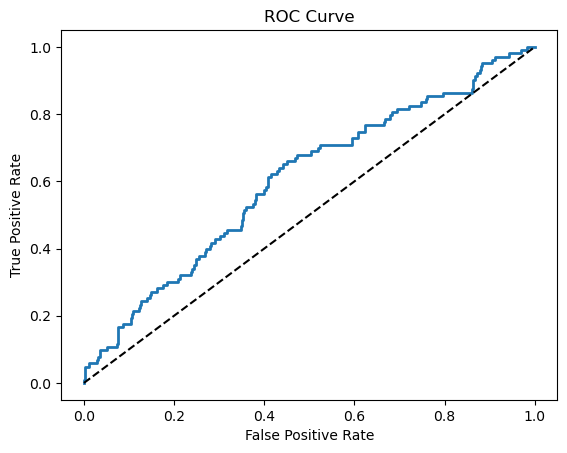

In [132]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') # dashed diagonal
[...] # Add axis labels and grid
plot_roc_curve(fpr_sgd, tpr_sgd, label='SGD Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

Search các hyperparameters

In [133]:
#Dò thô
from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=sgd_clf,
    param_distributions={
        'alpha': [0.0001, 0.001, 0.01, 0.1],
        'penalty': ['l2', 'l1', 'elasticnet'],
    },
        n_iter=10,
        cv=6,
        random_state=42)

random_search.fit(X_train_final, y_train)

print("Best Hyperparameters:", random_search.best_params_)

Best Hyperparameters: {'penalty': 'l1', 'alpha': 0.1}


In [134]:
print("Best Estimator:", random_search.best_estimator_)

Best Estimator: SGDClassifier(alpha=0.1, penalty='l1', random_state=42)


In [135]:
from sklearn.model_selection import GridSearchCV

# 1. Khởi tạo lại mô hình gốc
sgd_clf = SGDClassifier(random_state=42)

param_grid_fine = [
    {
        'penalty': ['l2', 'l1'],
        # Trải dài từ mức mặc định (0.0001) lên đến mức Random Search tìm thấy (0.1)
        'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.15] 
    },
    {
        'penalty': ['elasticnet'],
        'alpha': [0.001, 0.01, 0.1],
        'l1_ratio': [0.15, 0.5, 0.8] 
    }
]

# 3. Chạy GridSearchCV (Vét cạn mọi ngóc ngách trong param_grid)
grid_search = GridSearchCV(
    estimator=sgd_clf,
    param_grid=param_grid_fine,
    cv=5,
    scoring='roc_auc', # Tiếp tục bám sát vào mục tiêu đẩy phồng ROC-AUC
    n_jobs=-1          # Tận dụng toàn bộ CPU để chạy cho nhanh
)

# 4. Fit vào dữ liệu Train
grid_search.fit(X_train_final, y_train)

# 5. Hyperparameters tốt nhất và điểm số tương ứng
final_best_model_sgd = grid_search.best_estimator_
print("Tham số tốt nhất:", grid_search.best_params_)
print("Điểm AUC cao nhất đạt được:", grid_search.best_score_)

Tham số tốt nhất: {'alpha': 0.01, 'penalty': 'l1'}
Điểm AUC cao nhất đạt được: 0.7269918229918231


In [136]:
y_scores_fine_tunned_sgd = cross_val_predict(final_best_model_sgd, X_train_final, y_train, cv=5, method='decision_function')
print("Cross-validation scores:", y_scores)

Cross-validation scores: [-3.28576045e+01 -2.61592968e+01 -2.56798472e+01 -3.21152999e+01
 -2.30664488e+01 -1.07181219e+01 -2.29644135e+01 -1.26496554e+01
 -1.68668062e+01 -1.79114126e+01 -2.94855883e+01 -2.59775376e+01
 -2.01829741e+01 -2.71100370e+01 -1.56223378e+01 -2.04820058e+01
 -2.95405628e+01 -2.58369881e+01 -2.99983600e+01 -2.26060352e+01
 -2.74329231e+01 -2.20285158e+01 -2.36389898e+01 -2.44746366e+01
 -2.27226435e+01 -3.30798118e+01 -2.95664752e+01 -1.81958116e+01
 -1.78682912e+01 -2.90885270e+01 -2.16119500e+01 -2.75279637e+01
 -2.95400090e+01 -2.74768415e+01 -1.79410681e+01 -1.53711066e+01
 -2.02682981e+01 -1.48219680e+01 -2.29805031e+01 -1.70412796e+01
 -2.11221992e+01 -2.48961642e+01 -1.98995902e+01 -2.03766349e+01
 -1.78428222e+01 -3.53122659e+01 -2.18483694e+01 -2.61279062e+01
 -2.74607416e+01 -2.22089504e+01 -2.17021265e+01 -2.31156098e+01
 -1.28565299e+01 -1.71252249e+01 -1.51047120e+01 -2.31778418e+01
 -1.84270363e+01 -1.65302428e+01 -1.73456062e+01 -2.53858931e+01


In [137]:
fpr_fine_tunned_sgd, tpr_fine_tunned_sgd, thresholds_fine_tunned_sgd = roc_curve(y_train, y_scores_fine_tunned_sgd)

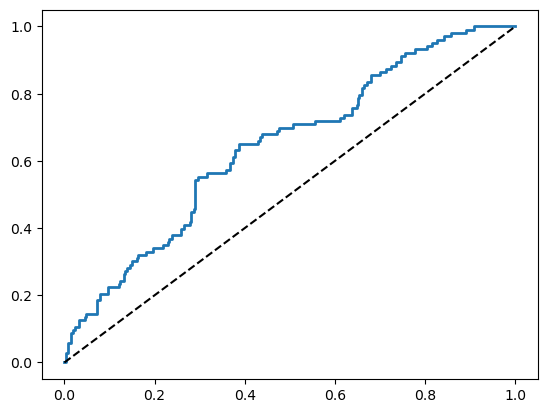

In [138]:
plot_roc_curve(fpr_fine_tunned_sgd, tpr_fine_tunned_sgd, label='Fine-tunned SGD')
plt.show()

In [139]:
from sklearn.metrics import classification_report, confusion_matrix

# TÌM THRESHOLD TỐI ƯU (Dựa trên đường cong ROC đã vẽ)
# Giả sử fpr_fine_tunned, tpr_fine_tunned, thresholds_fine_tunned được sinh ra từ roc_curve()
J_scores = tpr_fine_tunned_sgd - fpr_fine_tunned_sgd
optimal_idx = np.argmax(J_scores)
optimal_threshold = thresholds_fine_tunned_sgd[optimal_idx]

print(f"Ngưỡng (Threshold) tối ưu theo Youden's J: {optimal_threshold:.4f}")

Ngưỡng (Threshold) tối ưu theo Youden's J: -1.0062


In [140]:
# LẤY ĐIỂM SỐ DỰ ĐOÁN TRÊN TẬP TEST
# Nếu model dùng loss='log_loss' thì có predict_proba, nếu không dùng decision_function
if hasattr(final_best_model_sgd, "predict_proba"):
    y_test_scores = final_best_model_sgd.predict_proba(X_test_final)[:, 1]
else:
    y_test_scores = final_best_model_sgd.decision_function(X_test_final)

# ÁP DỤNG THRESHOLD VÀO TẬP TEST ĐỂ RA QUYẾT ĐỊNH (0 hoặc 1)
y_test_pred_optimal = (y_test_scores >= optimal_threshold).astype(int)

# 4. ĐÁNH GIÁ CHẤT LƯỢNG CUỐI CÙNG
print("\n--- MA TRẬN NHẦM LẪN (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_test_pred_optimal))

print("\n--- BÁO CÁO PHÂN LOẠI (Classification Report) ---")
print(classification_report(y_test, y_test_pred_optimal))


--- MA TRẬN NHẦM LẪN (Confusion Matrix) ---
[[89 23]
 [17 21]]

--- BÁO CÁO PHÂN LOẠI (Classification Report) ---
              precision    recall  f1-score   support

           0       0.84      0.79      0.82       112
           1       0.48      0.55      0.51        38

    accuracy                           0.73       150
   macro avg       0.66      0.67      0.66       150
weighted avg       0.75      0.73      0.74       150



Randomforest

In [141]:
from sklearn.ensemble import RandomForestClassifier
rdf_clf = RandomForestClassifier(random_state=42)
# rdf_clf.fit(X_train_final, y_train)

In [142]:
from sklearn.model_selection import cross_val_predict

y_scores_rdf = cross_val_predict(rdf_clf, X_train_final, y_train, cv=6, method='predict_proba')
print("Cross-validation scores:", y_scores_rdf)


Cross-validation scores: [[0.97 0.03]
 [0.9  0.1 ]
 [0.97 0.03]
 ...
 [0.45 0.55]
 [0.46 0.54]
 [0.52 0.48]]


In [143]:
y_scores_forest = y_scores_rdf[:, 1] 

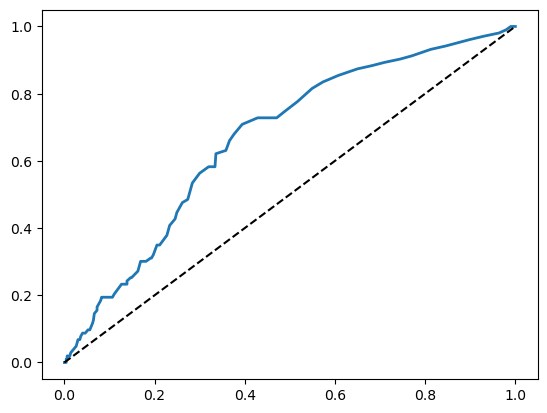

In [144]:
from sklearn.metrics import roc_curve

fpr_rdf, tpr_rdf, thresholds_rdf = roc_curve(y_train, y_scores_forest)
plot_roc_curve(fpr_rdf, tpr_rdf, label='Random Forest Classifier')
plt.show()

In [145]:
#Dò thô
from sklearn.model_selection import RandomizedSearchCV

# Các tham số chuẩn cho Random Forest
param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],      # Số lượng cây
    'max_depth': [10, 20, 30, None],           # Độ sâu tối đa của cây (None là không giới hạn)
    'min_samples_split': [2, 5, 10],           # Số lượng mẫu tối thiểu để tách một nút
    'min_samples_leaf': [1, 2, 4],             # Số lượng mẫu tối thiểu ở một lá
    'max_features': ['sqrt', 'log2']           # Số lượng đặc trưng (features) xét đến khi tách nút
}

random_search = RandomizedSearchCV(
    estimator=rdf_clf,
    param_distributions=param_dist_rf,
    n_iter=10,       # Random Forest chạy khá chậm, n_iter=10 là mức thử nghiệm hợp lý
    cv=6,            # Số lần chia dữ liệu để đánh giá (Cross-validation folds)
    n_jobs=-1,       # Bắt buộc: Chạy đa luồng (tận dụng toàn bộ nhân CPU) để tránh chờ đợi lâu
    random_state=42
)

random_search.fit(X_train_final, y_train)

print("Best Hyperparameters:", random_search.best_params_)
print("Best Estimator:", random_search.best_estimator_)

Best Hyperparameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}
Best Estimator: RandomForestClassifier(max_depth=10, max_features='log2', min_samples_split=10,
                       n_estimators=200, random_state=42)


In [146]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Khởi tạo lại mô hình gốc cho Random Forest
rdf_clf = RandomForestClassifier(random_state=42)

# 2. Xây dựng lưới tinh chỉnh bám sát kết quả dò thô
param_grid_fine = [
    {
        'n_estimators': [150, 200, 250],      # Quanh mốc 200
        'max_depth': [8, 10, 12, 15],         # Quanh mốc 10
        'min_samples_split': [8, 10, 12],     # Quanh mốc 10
        'min_samples_leaf': [1, 2, 3],        # Quanh mốc 1
        'max_features': ['log2']              # Giữ nguyên log2 vì dò thô đã chọn
    }
]

# 3. Chạy GridSearchCV (Vét cạn lưới tham số mới)
grid_search = GridSearchCV(
    estimator=rdf_clf,
    param_grid=param_grid_fine,
    cv=5,
    scoring='roc_auc', 
    n_jobs=-1          
)

# 4. Fit vào dữ liệu Train (Có thể mất thời gian do Random Forest khá nặng)
grid_search.fit(X_train_final, y_train)

# 5. Chiêm ngưỡng kết quả cuối cùng
final_best_model_rdf = grid_search.best_estimator_
print("Tham số tốt nhất:", grid_search.best_params_)
print("Điểm AUC cao nhất đạt được:", grid_search.best_score_)

Tham số tốt nhất: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 200}
Điểm AUC cao nhất đạt được: 0.7699942279942279


In [147]:
y_scores_fine_tunned_rdf = cross_val_predict(final_best_model_rdf, X_train_final, y_train, cv=5, method='predict_proba')[:, 1]
print("Cross-validation scores:", y_scores_fine_tunned_rdf)

Cross-validation scores: [0.10192893 0.13923559 0.06829214 0.04077652 0.082612   0.13916529
 0.09944534 0.14511245 0.15409309 0.08648593 0.07642079 0.07922077
 0.08305681 0.09259508 0.23879597 0.0979558  0.06210523 0.13466196
 0.03890958 0.1099444  0.04209674 0.14461583 0.09774561 0.06598521
 0.08620918 0.02814055 0.06011057 0.07688301 0.21915525 0.02898258
 0.04637295 0.07054678 0.10786219 0.10498933 0.05916169 0.08112637
 0.0687013  0.21465767 0.06509289 0.19816268 0.06288225 0.05708762
 0.18127041 0.06374682 0.12202318 0.04909336 0.06502845 0.03671315
 0.06270142 0.05214482 0.04179439 0.06081669 0.23701014 0.07160825
 0.19314151 0.10629221 0.06603419 0.15698016 0.16708857 0.09257931
 0.1170992  0.08449484 0.0355553  0.23139425 0.11691361 0.17465722
 0.19670633 0.30776258 0.141423   0.04013916 0.04276039 0.09857534
 0.15072891 0.20429238 0.16497403 0.10764251 0.1108348  0.08447722
 0.1941302  0.12352636 0.09447122 0.02729805 0.40485369 0.09583934
 0.13341855 0.05166421 0.06010452 0.0

In [148]:
fpr_fine_tunned_rdf, tpr_fine_tunned_rdf, thresholds_fine_tunned_rdf = roc_curve(y_train, y_scores_fine_tunned_rdf)

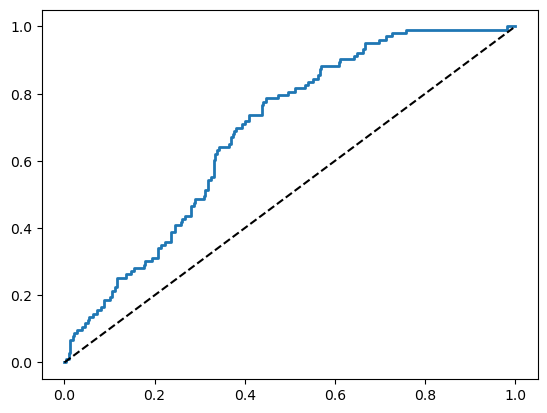

In [149]:
plot_roc_curve(fpr_fine_tunned_rdf, tpr_fine_tunned_rdf, label='Fine-tunned RDF')
plt.show()

In [150]:
from sklearn.metrics import roc_curve, classification_report, confusion_matrix
import numpy as np

# 1. Lấy xác suất dự đoán cho lớp 1 (có quay lại) trên tập Train
y_train_proba = final_best_model_rdf.predict_proba(X_train_final)[:, 1]

# 2. Tính toán ngay các giá trị dùng cho ROC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_train, y_train_proba)

# 3. Tìm Threshold tối ưu dựa trên Youden's J Index
J_scores = tpr_rf - fpr_rf
optimal_idx = np.argmax(J_scores)
optimal_threshold = thresholds_rf[optimal_idx]

print(f"Ngưỡng (Threshold) tối ưu theo Youden's J: {optimal_threshold:.4f}")

Ngưỡng (Threshold) tối ưu theo Youden's J: 0.2661


In [151]:
# 1. LẤY XÁC SUẤT DỰ ĐOÁN TRÊN TẬP TEST (Chỉ lấy cột xác suất của lớp 1)
y_test_proba = final_best_model_rdf.predict_proba(X_test_final)[:, 1]

# 2. ÁP DỤNG THRESHOLD TỐI ƯU ĐỂ RA QUYẾT ĐỊNH (0 hoặc 1)
y_test_pred_optimal = (y_test_proba >= optimal_threshold).astype(int)

# 3. ĐÁNH GIÁ CHẤT LƯỢNG CUỐI CÙNG TRÊN TẬP TEST
print("\n--- MA TRẬN NHẦM LẪN (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_test_pred_optimal))

print("\n--- BÁO CÁO PHÂN LOẠI (Classification Report) ---")
print(classification_report(y_test, y_test_pred_optimal))


--- MA TRẬN NHẦM LẪN (Confusion Matrix) ---
[[62 50]
 [ 7 31]]

--- BÁO CÁO PHÂN LOẠI (Classification Report) ---
              precision    recall  f1-score   support

           0       0.90      0.55      0.69       112
           1       0.38      0.82      0.52        38

    accuracy                           0.62       150
   macro avg       0.64      0.68      0.60       150
weighted avg       0.77      0.62      0.64       150



So sánh hai model bằng ROC-AUC

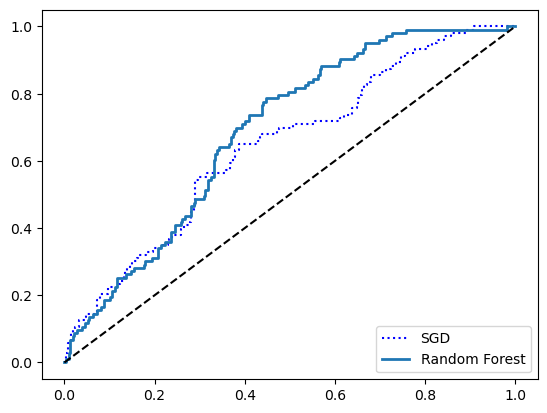

In [152]:
plt.plot(fpr_fine_tunned_sgd, tpr_fine_tunned_sgd, "b:", label="SGD")
plot_roc_curve(fpr_fine_tunned_rdf, tpr_fine_tunned_rdf, "Random Forest")
plt.legend(loc="lower right")
plt.show()

Dựa trên toàn bộ quy trình xây dựng mô hình học máy để dự đoán "Khách hàng có quay lại trong vòng 30 ngày hay không" (`will_return_within_30_days`) mà bạn đã thực hiện, dưới đây là các phân tích và gợi ý để bạn hoàn thiện 2 phần cuối cùng của bài báo cáo/notebook:

### 1. Kết luận và Đề xuất ứng dụng kinh doanh thực tế

**A. Phân loại nhóm khách hàng để tối ưu chi phí (Dựa trên Xác suất dự đoán - Predict Proba):**
Việc mô hình Random Forest trả về xác suất từ 0 đến 1 cho phép doanh nghiệp chia khách hàng thành 3 nhóm thay vì chỉ dùng quyết định cứng (0 hoặc 1):
*   **Nhóm chắc chắn quay lại (Xác suất > 0.7):** Đây là nhóm khách hàng trung thành (thường có RFM tốt: Frequency cao, Recency thấp). 
    *   *Hành động:* Không cần gửi mã giảm giá (offer_value) cao để tránh lãng phí ngân sách Marketing (margin erosion). Chỉ gửi email chăm sóc hoặc giới thiệu sản phẩm mới.
*   **Nhóm dao động / Nguy cơ rời bỏ (Xác suất từ ngưỡng Threshold tối ưu đến 0.7):** Họ đang phân vân hoặc chu kỳ mua sắm đang giãn ra.
    *   *Hành động:* Đây là nhóm mục tiêu vàng của chiến dịch (Campaign). Gửi ngay các ưu đãi mạnh (`offer_value` lớn, ví dụ: giảm 20% hoặc Freeship) để kéo họ quay lại chốt đơn trong mốc 30 ngày.
*   **Nhóm chắc chắn rời bỏ / Churn (Xác suất rất thấp < ngưỡng Threshold):**
    *   *Hành động:* Đưa vào danh sách "Win-back campaign" (Chiến dịch giành lại) với chu kỳ dài hạn (như dịp sale lớn cuối năm, Black Friday) thay vì theo đuổi tốn kém trong ngắn hạn 30 ngày.

**B. Thời điểm gửi thông điệp (When):**
*   Dựa vào đặc trưng `Recency` (Số ngày kể từ lần mua cuối). Thay vì đợi đến ngày thứ 29 mới gửi ưu đãi, hệ thống có thể trigger (kích hoạt) chiến dịch tự động vào **ngày thứ 20 - 25** đối với các khách hàng bị mô hình dự đoán là 0 (Không quay lại).

---

### 2. Nhận diện hạn chế và Hướng cải thiện (Future Works)

**A. Hạn chế của quá trình hiện tại:**
*   **Feature Engineering (Đặc trưng dữ liệu):** Bộ ba RFM (Recency, Frequency, Monetary) là nền tảng tốt nhưng chưa đủ độ sâu. Chúng ta chưa khai thác được tính mùa vụ (Seasonality) hoặc chu kỳ mua sắm cá nhân (Ví dụ: khách hàng A cứ chu kỳ 45 ngày mới mua một lần do xài hết sản phẩm, thì việc họ không quay lại trong 30 ngày là bình thường, không phải rời bỏ).
*   **Sự tương tác với Marketing:** Chưa có các đặc trưng phản ánh "Khách hàng phản ứng thế nào với các touchpoints ở quá khứ". (Ví dụ: Tỉ lệ mở email, Tỉ lệ dùng voucher trong quá khứ).
*   **Outlier & Imbalanced Data:** Cột `target` cho bài toán quay lại mua hàng thường bị mất cân bằng (Imbalanced class). Việc tìm ngưỡng Threshold (Youden's J) đã giúp ích, nhưng chất lượng gốc của mô hình có thể bị ảnh hưởng nếu chưa xử lý SMOTE hoặc chỉnh class weight.

**B. Hướng cải thiện cho tương lai:**
1.  **Thử nghiệm Gradient Boosting:** Mặc dù Random Forest tốt, nhưng các thuật toán tiên tiến như **XGBoost, LightGBM** hoặc **CatBoost** thường cho hiệu suất vượt trội (Điểm ROC-AUC cao hơn hẳn) đối với tập dữ liệu dạng bảng (tabular data) có chứa nhiều biến phân loại (categorical) và giá trị thiếu (missing values).
2.  **Tạo thêm biến mới (Advanced Feature Creation):** 
    *   *Time-between-purchases:* Khoảng thời gian trung bình giữa 2 lần mua sắm liên tiếp của từng khách hàng.
    *   *Offer Affinity:* Khách hàng chuộng voucher giảm tiền mặt hay giảm phần trăm hơn?
3.  **Customer Time-Series:** Thay vì bài toán phân loại nhị phân tĩnh (Binary Classification), có thể chuyển hướng sang mô hình Phân tích sinh tồn (Survival Analysis) để dự đoán chính xác *bao nhiêu ngày nữa* họ sẽ quay lại mua hàng.